[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ronniewillaert/SPM-Textbook-Python/blob/main/notebooks/part-01-foundations/ch02_tip_sample_interactions/AFM_Force_Distance_LJ_Hertz_Adhesion.ipynb)

# Tip–Sample Interactions: From Atomic Forces to AFM Measurements
## Interactive Companion to Chapter 2 — *Scanning Probe Microscopy*

This notebook accompanies **Chapter 2** of the textbook *Scanning Probe Microscopy*.

After completing this notebook you will be able to:

- Visualise the Lennard-Jones potential and force, and understand the role of ε and σ.
- Compare atomic pair interactions with macroscopic sphere–plane van der Waals forces.
- Explore electrostatic screening (Debye length) and DLVO theory interactively.
- Estimate capillary forces and understand why adhesion is larger in air.
- Analyse jump-to-contact as a mechanical instability of the cantilever–interaction system.
- Compare Hertz, JKR, and DMT contact mechanics models and compute the Tabor parameter.
- Simulate complete AFM force–distance curves with adhesion and hysteresis.
- Explore loading-rate dependence of molecular rupture forces.
- Perform parameter sweeps to evaluate how experimental choices affect measured quantities.

**Central idea — A force–distance curve is the measurable outcome of a coupled system: atomic interaction + surface thermodynamics + contact mechanics + cantilever dynamics.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ---------- Physical constants ----------
k_B   = 1.380649e-23    # Boltzmann constant        (J/K)
T     = 298             # Room temperature          (K)
h_bar = 1.054571817e-34 # Reduced Planck constant   (J·s)
m_e   = 9.10938e-31     # Electron mass             (kg)
e_0   = 1.602176634e-19 # Elementary charge         (C)
eps_0 = 8.8541878128e-12 # Vacuum permittivity      (F/m)

print("Physical constants loaded ✓")

Physical constants loaded ✓


In [2]:
# If widgets do not render, run this cell once (Colab).
try:
    from ipywidgets import interact, FloatLogSlider, FloatSlider, IntSlider, Dropdown, HTML, fixed
    import ipywidgets as widgets
    from IPython.display import display, Markdown, clear_output
    print("Widgets ready ✓")
except:
    print("ipywidgets not available, installing...")
    import subprocess
    subprocess.check_call(['pip', '-q', 'install', 'ipywidgets'])
    from ipywidgets import interact, FloatLogSlider, FloatSlider, IntSlider, Dropdown, HTML, fixed
    import ipywidgets as widgets
    from IPython.display import display, Markdown, clear_output
    print("Widgets ready ✓")

Widgets ready ✓


---
## 1. Lennard-Jones Potential & Force — Understanding Atomic Interactions

The **Lennard-Jones (LJ) potential** models the interaction between two neutral atoms or molecules:

$$U(r) = 4\epsilon \left[ \left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^{6} \right]$$

The corresponding **force** is:

$$F(r) = -\frac{dU}{dr} = 24\epsilon \left[ 2\left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^{6} \right] \frac{1}{r}$$

**Parameters:**
- **ε** (epsilon): depth of the potential well, ~0.1–10 meV (1.6×10⁻²² to 1.6×10⁻²¹ J) for typical atom pairs
- **σ** (sigma): characteristic length scale, ~0.2–0.5 nm (diameter where U ≈ 0)
- **r₀** (equilibrium separation): $r_0 = 2^{1/6} \sigma \approx 1.122 \sigma$

**Key insight:** The repulsive $r^{-12}$ term dominates at short range, while the attractive van der Waals $r^{-6}$ term dominates at larger distances (Section §2.2). The stable equilibrium lies at $r_0$, where $dU/dr = 0$.

### Typical Values (§2.2.8)

| Pair | ε (eV) | σ (nm) | U_min (meV) |
|---|---|---|---|
| Ar–Ar | 0.010 | 0.34 | –10 |
| CH₄–CH₄ | 0.049 | 0.37 | –49 |
| Au–Au | 0.04 | 0.29 | –40 |

**Reference:** See textbook Table 2.1 and Section §2.2.

  LJ Parameters:
  ─────────────────────────────────
  ε       = 1.000 meV
  σ       = 0.300 nm
  r₀      = 0.337 nm  (equilibrium)
  U_min   = -1.000 meV  (at r₀)

  Computed minimum: r = 0.3365 nm, U = -1.000 meV

  U ≈ 0 at r ≈ 0.900 nm  (≈ 3.00×σ)



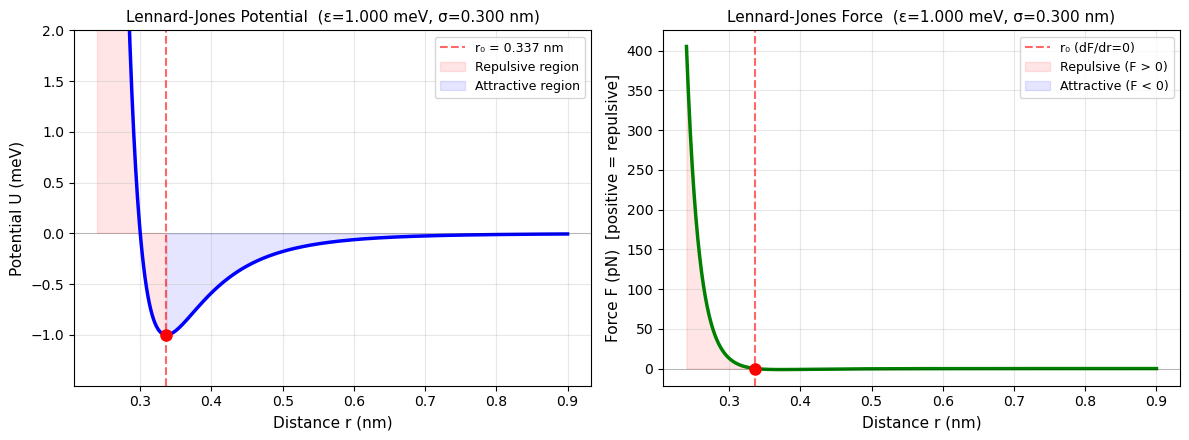

interactive(children=(FloatLogSlider(value=1.0, description='ε (meV)', max=1.0, min=-3.0, style=SliderStyle(de…

In [3]:
def interactive_lj(epsilon_meV=1.0, sigma_nm=0.30):
    epsilon_J = epsilon_meV * 1e-3 * e_0  # meV to J
    sigma_m = sigma_nm * 1e-9              # nm to m
    r0_nm = (2**(1/6)) * sigma_nm
    
    # Range from 0.8*sigma to 3*sigma
    r_nm = np.linspace(0.8*sigma_nm, 3*sigma_nm, 1000)
    r_m = r_nm * 1e-9
    
    # LJ potential
    U = 4*epsilon_J * ((sigma_m/r_m)**12 - (sigma_m/r_m)**6)
    
    # LJ force (positive = repulsive)
    F = 24*epsilon_J * (2*(sigma_m/r_m)**12 - (sigma_m/r_m)**6) / r_m
    
    print(f"  LJ Parameters:")
    print(f"  ─────────────────────────────────")
    print(f"  ε       = {epsilon_meV:.3f} meV")
    print(f"  σ       = {sigma_nm:.3f} nm")
    print(f"  r₀      = {r0_nm:.3f} nm  (equilibrium)")
    print(f"  U_min   = {4*epsilon_J*(-1/4)*1e3/e_0:.3f} meV  (at r₀)")
    print()
    
    # Find minimum (should be at r0)
    idx_min = np.argmin(U)
    r_min = r_nm[idx_min]
    U_min = U[idx_min]
    print(f"  Computed minimum: r = {r_min:.4f} nm, U = {U_min*1e3/e_0:.3f} meV")
    print()
    
    # Find zero crossing (repulsive→attractive transition)
    zero_idx = np.argmin(np.abs(U))
    if zero_idx < len(U):
        r_zero = r_nm[zero_idx]
        print(f"  U ≈ 0 at r ≈ {r_zero:.3f} nm  (≈ {r_zero/sigma_nm:.2f}×σ)")
    print()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
    
    # --- Potential ---
    ax1.plot(r_nm, U*1e3/e_0, 'b-', lw=2.5)
    ax1.axhline(0, color='k', lw=0.5, alpha=0.3)
    ax1.axvline(r0_nm, color='r', ls='--', alpha=0.6, label=f'r₀ = {r0_nm:.3f} nm')
    ax1.plot(r0_nm, -1*epsilon_meV, 'ro', ms=8, zorder=5)
    
    ax1.fill_between(r_nm[r_nm < r0_nm], U[r_nm < r0_nm]*1e3/e_0, 0, 
                      color='red', alpha=0.1, label='Repulsive region')
    ax1.fill_between(r_nm[r_nm >= r0_nm], U[r_nm >= r0_nm]*1e3/e_0, 0, 
                      color='blue', alpha=0.1, label='Attractive region')
    
    ax1.set_xlabel("Distance r (nm)", fontsize=11)
    ax1.set_ylabel("Potential U (meV)", fontsize=11)
    ax1.set_title(f"Lennard-Jones Potential  (ε={epsilon_meV:.3f} meV, σ={sigma_nm:.3f} nm)", fontsize=11)
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(min(U*1e3/e_0)*1.5, 2)
    
    # --- Force ---
    ax2.plot(r_nm, F*1e12, 'g-', lw=2.5)  # Convert to pN
    ax2.axhline(0, color='k', lw=0.5, alpha=0.3)
    ax2.axvline(r0_nm, color='r', ls='--', alpha=0.6, label=f'r₀ (dF/dr=0)')
    ax2.plot(r0_nm, 0, 'ro', ms=8, zorder=5)
    
    ax2.fill_between(r_nm[r_nm < r0_nm], 0, F[r_nm < r0_nm]*1e12, 
                      color='red', alpha=0.1, label='Repulsive (F > 0)')
    ax2.fill_between(r_nm[r_nm >= r0_nm], 0, F[r_nm >= r0_nm]*1e12, 
                      color='blue', alpha=0.1, label='Attractive (F < 0)')
    
    ax2.set_xlabel("Distance r (nm)", fontsize=11)
    ax2.set_ylabel("Force F (pN)  [positive = repulsive]", fontsize=11)
    ax2.set_title(f"Lennard-Jones Force  (ε={epsilon_meV:.3f} meV, σ={sigma_nm:.3f} nm)", fontsize=11)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

_ = interact(
    interactive_lj,
    epsilon_meV=FloatLogSlider(value=1.0, base=10, min=-3, max=1, step=0.1,
                               description='ε (meV)', style={'description_width': 'initial'}),
    sigma_nm=FloatSlider(value=0.30, min=0.2, max=0.5, step=0.01,
                         description='σ (nm)', style={'description_width': 'initial'})
)

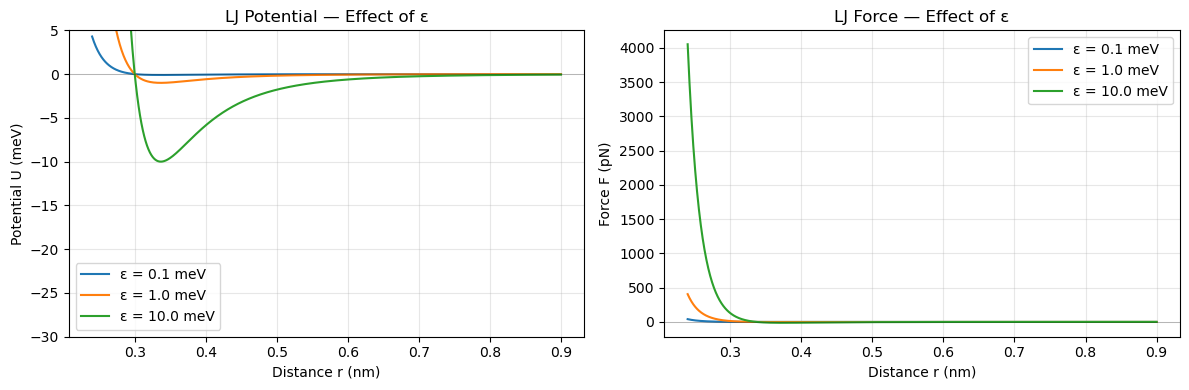

In [4]:
# Static reference: Compare different ε values
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sigma_ref = 0.30  # nm
sigma_m = sigma_ref * 1e-9

r_nm = np.linspace(0.8*sigma_ref, 3*sigma_ref, 1000)
r_m = r_nm * 1e-9

for eps_meV in [0.1, 1.0, 10.0]:
    eps_J = eps_meV * 1e-3 * e_0
    U = 4*eps_J * ((sigma_m/r_m)**12 - (sigma_m/r_m)**6)
    F = 24*eps_J * (2*(sigma_m/r_m)**12 - (sigma_m/r_m)**6) / r_m
    
    axes[0].plot(r_nm, U*1e3/e_0, label=f'ε = {eps_meV} meV')
    axes[1].plot(r_nm, F*1e12, label=f'ε = {eps_meV} meV')

axes[0].axhline(0, color='k', lw=0.5, alpha=0.3)
axes[0].set_xlabel("Distance r (nm)")
axes[0].set_ylabel("Potential U (meV)")
axes[0].set_title("LJ Potential — Effect of ε")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-30, 5)

axes[1].axhline(0, color='k', lw=0.5, alpha=0.3)
axes[1].set_xlabel("Distance r (nm)")
axes[1].set_ylabel("Force F (pN)")
axes[1].set_title("LJ Force — Effect of ε")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 2. Van der Waals Sphere–Plane Interaction

When a macroscopic sphere (tip) approaches a flat surface, the interaction can be computed by integrating pair-wise LJ potentials over all atom-atom pairs. For a sphere of radius **R** at distance **D** from a plane, the **Hamaker approach** gives:

$$F(D) = -\frac{A_H \, R}{6 D^2}$$

where **A_H** is the **Hamaker constant** (~10⁻²¹–10⁻¹⁹ J for typical material combinations).

**Key insight (§2.1.2, §2.2.8):** The force scales as:
- With sphere radius: $F \propto R$ (larger sphere → larger force)
- With distance: $F \propto D^{-2}$ (falls off quickly)
- Compare to atom-atom (LJ): $F \propto r^{-7}$ at long range

This means macroscopic van der Waals forces are much longer-ranged than molecular forces.

### Hamaker Constant Typical Values (§2.4)

| Material pair | A_H (J) | A_H (10⁻²⁰ J) |
|---|---|---|
| Au–Au in vacuum | 4×10⁻¹⁹ | 40 |
| Au–Au in water | 4×10⁻²⁰ | 0.4 |
| SiO₂–SiO₂ in vacuum | 6.5×10⁻²⁰ | 6.5 |
| Polystyrene–Polystyrene in vacuum | 3.6×10⁻²⁰ | 3.6 |

**Reference:** Section §2.2.8, Table 2.2 in textbook.

  Van der Waals Sphere-Plane Interaction
  ─────────────────────────────────────
  Hamaker constant  A_H = 1.000e-20 J  (10^-20.0)
  Sphere radius      R  = 20.0 nm
  Distance range      D = 0.5–100.0 nm

  At D =   1.0 nm:  F = -3.333e-11 N  (-33.333 pN)
  At D =   5.0 nm:  F = -1.333e-12 N  (-1.333 pN)
  At D =  10.0 nm:  F = -3.333e-13 N  (-0.333 pN)
  At D =  50.0 nm:  F = -1.333e-14 N  (-0.013 pN)



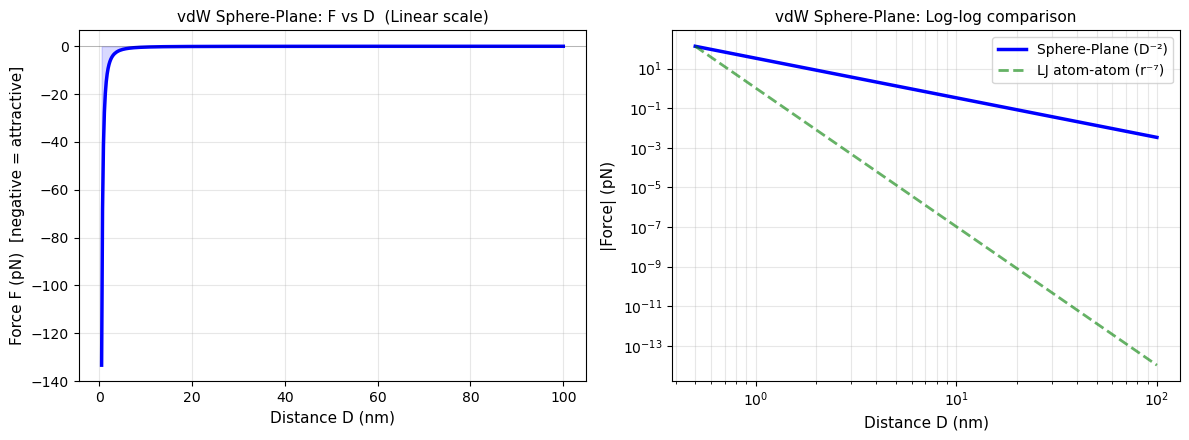

interactive(children=(FloatSlider(value=-20.0, description='log₁₀(A_H/J)', max=-18.0, min=-22.0, step=0.5, sty…

In [5]:
def interactive_vdw_sphere_plane(A_H_exp=-20, R_nm=20, D_min_nm=0.5, D_max_nm=100):
    A_H = 10**A_H_exp  # Hamaker constant in J
    R_m = R_nm * 1e-9   # Tip radius in m
    
    D_range_nm = np.linspace(D_min_nm, D_max_nm, 500)
    D_range_m = D_range_nm * 1e-9
    
    # Sphere-plane force: F = -A_H * R / (6 * D^2)
    # Negative = attractive
    F_vdw = -A_H * R_m / (6 * D_range_m**2)
    
    print(f"  Van der Waals Sphere-Plane Interaction")
    print(f"  ─────────────────────────────────────")
    print(f"  Hamaker constant  A_H = {A_H:.3e} J  (10^{A_H_exp:.1f})")
    print(f"  Sphere radius      R  = {R_nm:.1f} nm")
    print(f"  Distance range      D = {D_min_nm:.1f}–{D_max_nm:.1f} nm")
    print()
    
    # Force at a few distances
    for D_test_nm in [1, 5, 10, 50]:
        if D_min_nm <= D_test_nm <= D_max_nm:
            D_test_m = D_test_nm * 1e-9
            F_test = -A_H * R_m / (6 * D_test_m**2)
            print(f"  At D = {D_test_nm:5.1f} nm:  F = {F_test:.3e} N  ({F_test*1e12:.3f} pN)")
    print()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
    
    # Linear scale
    ax1.plot(D_range_nm, F_vdw*1e12, 'b-', lw=2.5)
    ax1.set_xlabel("Distance D (nm)", fontsize=11)
    ax1.set_ylabel("Force F (pN)  [negative = attractive]", fontsize=11)
    ax1.set_title(f"vdW Sphere-Plane: F vs D  (Linear scale)", fontsize=11)
    ax1.axhline(0, color='k', lw=0.5, alpha=0.3)
    ax1.grid(True, alpha=0.3)
    ax1.fill_between(D_range_nm, 0, F_vdw*1e12, color='blue', alpha=0.15)
    
    # Log-log scale
    ax2.loglog(D_range_nm, np.abs(F_vdw)*1e12, 'b-', lw=2.5, label='Sphere-Plane (D⁻²)')
    
    # For comparison: LJ force scaling (r^-7 at long range)
    D_lj = np.linspace(0.5, 100, 200)
    F_lj_scale = (D_lj[0]/D_lj)**7  # Normalized
    ax2.loglog(D_lj, F_lj_scale*np.abs(F_vdw[0])*1e12, 'g--', lw=2, alpha=0.6, label='LJ atom-atom (r⁻⁷)')
    
    ax2.set_xlabel("Distance D (nm)", fontsize=11)
    ax2.set_ylabel("|Force| (pN)", fontsize=11)
    ax2.set_title(f"vdW Sphere-Plane: Log-log comparison", fontsize=11)
    ax2.grid(True, which='both', alpha=0.3)
    ax2.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()

_ = interact(
    interactive_vdw_sphere_plane,
    A_H_exp=FloatSlider(value=-20, min=-22, max=-18, step=0.5,
                        description='log₁₀(A_H/J)', style={'description_width': 'initial'}),
    R_nm=FloatSlider(value=20, min=5, max=100, step=5,
                     description='R (nm)', style={'description_width': 'initial'}),
    D_min_nm=FloatSlider(value=0.5, min=0.1, max=2, step=0.1,
                         description='D_min (nm)', style={'description_width': 'initial'}),
    D_max_nm=FloatSlider(value=100, min=10, max=500, step=10,
                         description='D_max (nm)', style={'description_width': 'initial'})
)

---
## 3. Electrostatic Forces & Debye Screening

In aqueous solutions, mobile ions shield the electrostatic potential around a charged surface. The **Debye length** $\lambda_D$ characterises the screening distance:

$$\lambda_D = \sqrt{\frac{\epsilon_r \epsilon_0 k_B T}{2 n_0 e_0^2 I}}$$

where:
- $\epsilon_r$ = relative permittivity (80 for water)
- $n_0$ = molar concentration of salt (mol/m³)
- $I$ = ionic strength

For **monovalent ions** (like NaCl), a convenient approximation is:

$$\lambda_D \text{(nm)} \approx \frac{0.304}{\sqrt{c \text{(M)}}}$$

where $c$ is molar concentration in mol/L.

**Coulomb force in vacuum:**
$$F_\text{Coulomb} = \frac{q_1 q_2}{4\pi\epsilon_0 r^2}$$

**Screened Coulomb (Debye–Hückel):**
$$F_\text{screened} \propto e^{-r/\lambda_D} / r^2$$

**Key insight (§2.1.3):** In air, no screening → Coulomb dominates at large distances. In salt solution, screening drastically reduces electrostatic forces beyond $\lambda_D$.

### Typical Debye Lengths (§2.4)

| Concentration | λ_D (nm) | Regime |
|---|---|---|
| 1 mM | 10 | Partially screened |
| 10 mM | 3 | Well-screened |
| 100 mM | 1 | Strongly screened |
| 1 M | 0.3 | Highly screened |

**Reference:** Section §2.1.3, Figure 2.4 in textbook.

  Electrostatic Screening & Debye Length
  ─────────────────────────────────────
  Salt concentration    c = 0.010000 M
  Debye length       λ_D = 3.040 nm
  Charge 1              q₁ = 1 e₀
  Charge 2              q₂ = 1 e₀

  Coulomb force (vacuum) at r = 1.0 nm: F = 2.307e-10 N

  Regime: Well-screened



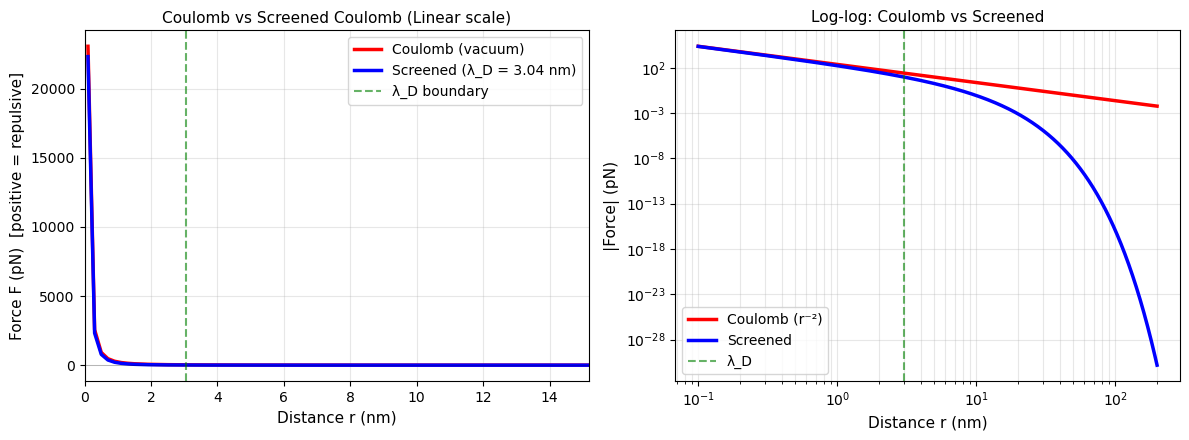

interactive(children=(FloatLogSlider(value=0.01, description='c (M)', max=0.0, min=-6.0, step=0.5, style=Slide…

In [6]:
def interactive_debye(concentration_M=0.01, charge1_e=1, charge2_e=1):
    '''
    concentration_M: molar concentration in mol/L
    charge1_e, charge2_e: charges in units of elementary charge
    '''
    # Compute Debye length
    lambda_D_nm = 0.304 / np.sqrt(max(concentration_M, 1e-6))
    
    # Coulomb force in vacuum at 1 nm
    q1 = charge1_e * e_0
    q2 = charge2_e * e_0
    r_test_nm = 1.0
    r_test_m = r_test_nm * 1e-9
    F_coulomb_1nm = (q1 * q2) / (4 * np.pi * eps_0 * r_test_m**2)
    
    print(f"  Electrostatic Screening & Debye Length")
    print(f"  ─────────────────────────────────────")
    print(f"  Salt concentration    c = {concentration_M:.6f} M")
    print(f"  Debye length       λ_D = {lambda_D_nm:.3f} nm")
    print(f"  Charge 1              q₁ = {charge1_e:.0f} e₀")
    print(f"  Charge 2              q₂ = {charge2_e:.0f} e₀")
    print()
    print(f"  Coulomb force (vacuum) at r = {r_test_nm} nm: F = {F_coulomb_1nm:.3e} N")
    print()
    
    if concentration_M < 1e-6:
        regime = "Dilute (minimal screening)"
    elif concentration_M < 0.01:
        regime = "Partially screened"
    elif concentration_M < 0.1:
        regime = "Well-screened"
    else:
        regime = "Strongly screened"
    print(f"  Regime: {regime}")
    print()
    
    # Distance range
    r_nm = np.linspace(0.1, 200, 1000)
    r_m = r_nm * 1e-9
    
    # Coulomb force (no screening)
    F_coulomb = (q1 * q2) / (4 * np.pi * eps_0 * r_m**2)
    
    # Debye-screened force (Coulomb × exp(-r/λ_D))
    lambda_D_m = lambda_D_nm * 1e-9
    F_screened = F_coulomb * np.exp(-r_m / lambda_D_m)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
    
    # Linear scale
    ax1.plot(r_nm, F_coulomb*1e12, 'r-', lw=2.5, label='Coulomb (vacuum)')
    ax1.plot(r_nm, F_screened*1e12, 'b-', lw=2.5, label=f'Screened (λ_D = {lambda_D_nm:.2f} nm)')
    ax1.axvline(lambda_D_nm, color='g', ls='--', alpha=0.6, label='λ_D boundary')
    ax1.axhline(0, color='k', lw=0.5, alpha=0.3)
    ax1.set_xlabel("Distance r (nm)", fontsize=11)
    ax1.set_ylabel("Force F (pN)  [positive = repulsive]", fontsize=11)
    ax1.set_title("Coulomb vs Screened Coulomb (Linear scale)", fontsize=11)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, min(200, 5*lambda_D_nm))
    
    # Log-log scale
    ax2.loglog(r_nm, np.abs(F_coulomb)*1e12, 'r-', lw=2.5, label='Coulomb (r⁻²)')
    ax2.loglog(r_nm, np.abs(F_screened)*1e12, 'b-', lw=2.5, label=f'Screened')
    ax2.axvline(lambda_D_nm, color='g', ls='--', alpha=0.6, label='λ_D')
    ax2.set_xlabel("Distance r (nm)", fontsize=11)
    ax2.set_ylabel("|Force| (pN)", fontsize=11)
    ax2.set_title("Log-log: Coulomb vs Screened", fontsize=11)
    ax2.legend(fontsize=10)
    ax2.grid(True, which='both', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

_ = interact(
    interactive_debye,
    concentration_M=FloatLogSlider(value=0.01, base=10, min=-6, max=0, step=0.5,
                                   description='c (M)', style={'description_width': 'initial'}),
    charge1_e=FloatSlider(value=1, min=-2, max=2, step=0.5,
                          description='q₁ (e₀)', style={'description_width': 'initial'}),
    charge2_e=FloatSlider(value=1, min=-2, max=2, step=0.5,
                          description='q₂ (e₀)', style={'description_width': 'initial'})
)

---
## 4. DLVO Theory — Total Interaction Energy

**DLVO theory** (Derjaguin, Landau, Verwey, Overbeek) combines van der Waals attraction with electrostatic repulsion:

$$U_\text{total}(D) = U_\text{vdW} + U_\text{elec}$$

For a sphere above a plane:

$$U_\text{vdW} = -\frac{A_H R}{12 D}$$

$$U_\text{elec} \approx 2\pi \epsilon_r \epsilon_0 R \psi_0^2 \exp\left(-\frac{D}{\lambda_D}\right)$$

where $\psi_0$ is the surface potential.

**Key insight (§2.4):**
- At small D (< λ_D): **electrostatic repulsion dominates** → energy barrier ("primary minimum")
- At large D: **van der Waals attraction grows** → adhesion well ("secondary minimum")
- The **secondary minimum** is where particles often stick in solution
- The **primary minimum** is the only minimum in vacuum

The **energy barrier** determines stability:
$$\Delta U = U_\text{max} - U_\text{secondary}$$

If $\Delta U > k_B T$, the system is stable against thermal fluctuations.

### Typical DLVO Parameters (§2.4, Table 2.3)

| Parameter | Typical value |
|---|---|
| Hamaker A_H | 1×10⁻²¹–5×10⁻¹⁹ J |
| Surface potential ψ₀ | 10–100 mV |
| Debye length λ_D | 0.3–100 nm |
| Particle radius | 5–1000 nm |

**Reference:** Section §2.4, Figures 2.6–2.8 in textbook.

  DLVO Total Interaction Energy
  ─────────────────────────────
  Surface potential   ψ₀ = 50.0 mV
  Debye length       λ_D = 10.0 nm
  Hamaker constant   A_H = 1.000e-20 J
  Sphere radius        R = 50.0 nm

  Primary minimum:   D = 82.27 nm,  U = -2.23 meV
  Secondary minimum: D = 93.73 nm,  U = -2.48 meV
  Energy barrier:    D = 0.90 nm,  ΔU = 2886.96 meV
  ΔU / k_B T = 112.42  (>1: stable vs thermal fluctuations)



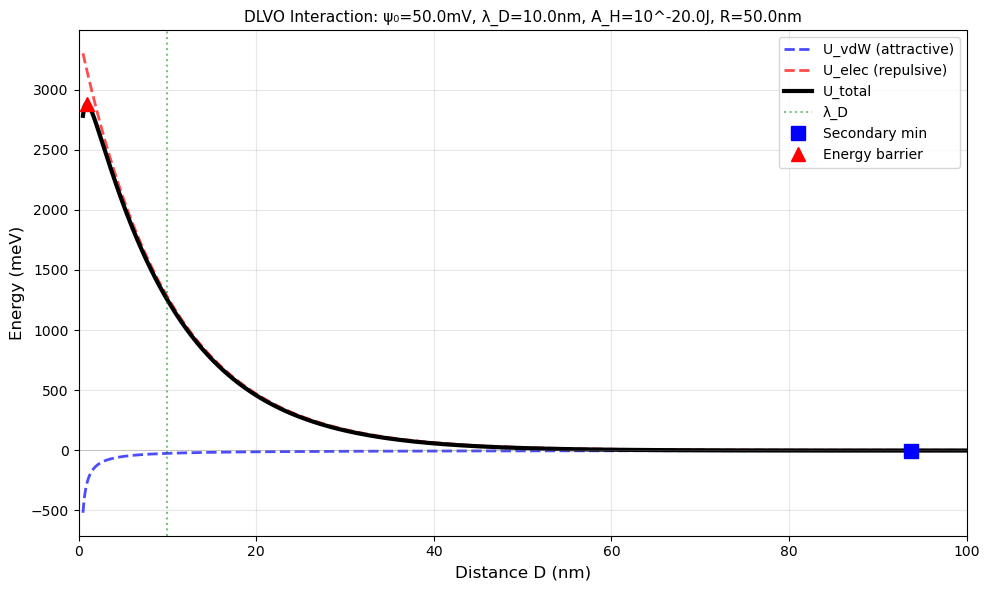

interactive(children=(FloatSlider(value=50.0, description='ψ₀ (mV)', max=200.0, min=1.0, step=5.0, style=Slide…

In [7]:
def interactive_dlvo(psi0_mV=50, lambda_D_nm=10, A_H_exp=-20, R_nm=50):
    '''
    psi0_mV: surface potential in mV
    lambda_D_nm: Debye length in nm
    A_H_exp: exponent for Hamaker constant (10^A_H_exp J)
    R_nm: sphere radius in nm
    '''
    psi0 = psi0_mV * 1e-3  # Convert to V
    lambda_D_m = lambda_D_nm * 1e-9
    A_H = 10**A_H_exp
    R_m = R_nm * 1e-9
    
    epsilon_r = 80  # for water
    
    # Distance range
    D_nm = np.linspace(0.5, 100, 1000)
    D_m = D_nm * 1e-9
    
    # vdW component
    U_vdW = -A_H * R_m / (12 * D_m)
    
    # Electrostatic component (Debye-Hückel approximation)
    U_elec = 2 * np.pi * epsilon_r * eps_0 * R_m * psi0**2 * np.exp(-D_m/lambda_D_m)
    
    # Total
    U_total = U_vdW + U_elec
    
    print(f"  DLVO Total Interaction Energy")
    print(f"  ─────────────────────────────")
    print(f"  Surface potential   ψ₀ = {psi0_mV:.1f} mV")
    print(f"  Debye length       λ_D = {lambda_D_nm:.1f} nm")
    print(f"  Hamaker constant   A_H = {A_H:.3e} J")
    print(f"  Sphere radius        R = {R_nm:.1f} nm")
    print()
    
    # Find extrema
    dU_dD = np.gradient(U_total, D_m)
    
    # Secondary minimum (at large D, attractive)
    secondary_idx = np.argmin(U_total)
    D_secondary = D_nm[secondary_idx]
    U_secondary = U_total[secondary_idx]
    
    # Primary minimum (if it exists, at small D)
    if np.any(U_total < U_secondary*0.9):
        primary_indices = np.where(U_total < U_secondary*0.9)[0]
        if len(primary_indices) > 0:
            D_primary = D_nm[primary_indices[0]]
            U_primary = U_total[primary_indices[0]]
            print(f"  Primary minimum:   D = {D_primary:.2f} nm,  U = {U_primary/e_0*1e3:.2f} meV")
    
    print(f"  Secondary minimum: D = {D_secondary:.2f} nm,  U = {U_secondary/e_0*1e3:.2f} meV")
    
    # Energy barrier
    max_idx = np.argmax(U_total)
    if 0 < max_idx < len(U_total)-1:
        U_barrier = U_total[max_idx]
        D_barrier = D_nm[max_idx]
        barrier_height = U_barrier - U_secondary
        print(f"  Energy barrier:    D = {D_barrier:.2f} nm,  ΔU = {barrier_height/e_0*1e3:.2f} meV")
        ratio_to_kT = barrier_height / (k_B * T)
        print(f"  ΔU / k_B T = {ratio_to_kT:.2f}  (>1: stable vs thermal fluctuations)")
    print()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot components
    ax.plot(D_nm, U_vdW/e_0*1e3, 'b--', lw=2, alpha=0.7, label='U_vdW (attractive)')
    ax.plot(D_nm, U_elec/e_0*1e3, 'r--', lw=2, alpha=0.7, label='U_elec (repulsive)')
    
    # Total
    ax.plot(D_nm, U_total/e_0*1e3, 'k-', lw=3, label='U_total')
    
    ax.axhline(0, color='gray', lw=0.5, alpha=0.5)
    ax.axvline(lambda_D_nm, color='g', ls=':', alpha=0.5, label='λ_D')
    
    # Mark extrema
    if secondary_idx is not None:
        ax.plot(D_secondary, U_secondary/e_0*1e3, 'bs', ms=10, zorder=5, label='Secondary min')
    
    if max_idx is not None and 0 < max_idx < len(U_total)-1:
        ax.plot(D_nm[max_idx], U_total[max_idx]/e_0*1e3, 'r^', ms=10, zorder=5, label='Energy barrier')
    
    ax.set_xlabel("Distance D (nm)", fontsize=12)
    ax.set_ylabel("Energy (meV)", fontsize=12)
    ax.set_title(f"DLVO Interaction: ψ₀={psi0_mV}mV, λ_D={lambda_D_nm}nm, A_H=10^{A_H_exp}J, R={R_nm}nm", fontsize=11)
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 100)
    
    plt.tight_layout()
    plt.show()

_ = interact(
    interactive_dlvo,
    psi0_mV=FloatSlider(value=50, min=1, max=200, step=5,
                        description='ψ₀ (mV)', style={'description_width': 'initial'}),
    lambda_D_nm=FloatLogSlider(value=10, base=10, min=-1, max=2, step=0.5,
                               description='λ_D (nm)', style={'description_width': 'initial'}),
    A_H_exp=FloatSlider(value=-20, min=-22, max=-18, step=0.5,
                        description='log₁₀(A_H)', style={'description_width': 'initial'}),
    R_nm=FloatSlider(value=50, min=5, max=200, step=5,
                     description='R (nm)', style={'description_width': 'initial'})
)

---
## 5. Capillary Forces — Why Adhesion is Larger in Air

When a liquid bridge forms between the tip and sample (e.g., water in humid air), a **capillary force** acts due to the curvature of the meniscus.

$$F_\text{cap} = 4\pi R \gamma_{\text{lv}} \cos(\theta)$$

where:
- **R** = tip radius
- **γ_lv** = liquid-vapor surface tension (0.02–0.073 N/m for water)
- **θ** = contact angle (0° = perfect wetting, 90° = no wetting)

**Key insight (§2.4.3):**
- In **dry conditions** (low humidity): minimal capillary force, adhesion mainly from vdW
- In **humid air** (high humidity): water bridge forms, capillary force dominates
- At 100% relative humidity, capillary force can be **100–1000× larger** than vdW force
- Even small changes in humidity dramatically affect measured adhesion

### Capillary Force Examples

For a 20 nm tip at different humidities (assuming water bridge forms):

| Humidity | Bridge size | F_cap | Dominant force |
|---|---|---|---|
| 0% (very dry) | None | ~0 | vdW only |
| 30% | Nanoscale | 0.1–1 nN | Mixed |
| 60% | Small | 1–10 nN | Capillary |
| 100% | Full bridge | 10–100 nN | Capillary |

**Reference:** Section §2.4.3, Figures 2.9–2.10 in textbook.

  Capillary Force Analysis
  ────────────────────────
  Tip radius              R = 20.0 nm
  Contact angle           θ = 0°
  Surface tension      γ_lv = 0.072 N/m
  Relative humidity        = 60%

  Capillary force     F_cap = 1.810e-08 N  (18.096 nN)
  vdW force (D=1nm)   F_vdW = 3.333e-11 N  (0.033 nN)
  Ratio F_cap / F_vdW      = 542.9×

  At 60.0% RH: Full water bridge expected



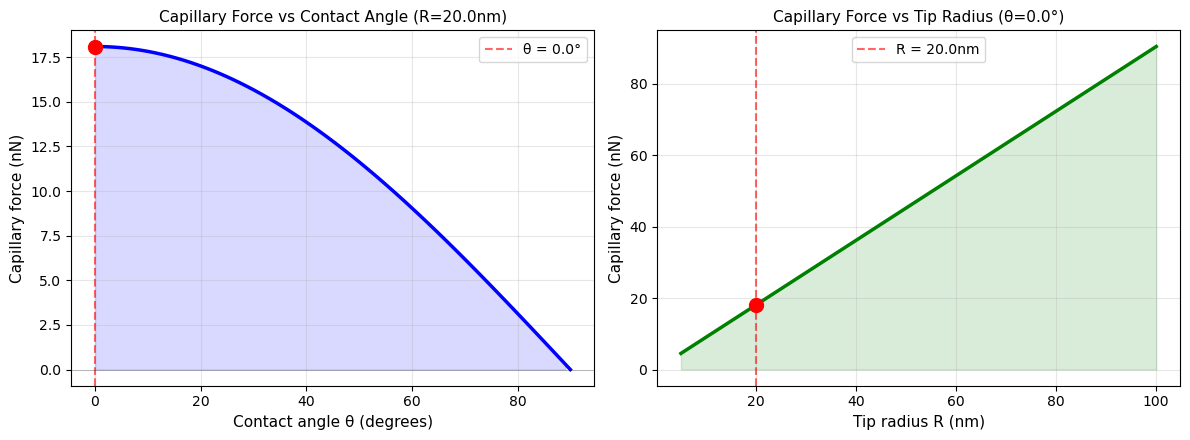

interactive(children=(FloatSlider(value=20.0, description='R (nm)', min=5.0, step=5.0, style=SliderStyle(descr…

In [8]:
def interactive_capillary(R_nm=20, contact_angle_deg=0, gamma_lv=0.072, humidity_percent=60):
    '''
    R_nm: tip radius in nm
    contact_angle_deg: contact angle in degrees
    gamma_lv: liquid-vapor surface tension in N/m
    humidity_percent: relative humidity (affects whether bridge forms)
    '''
    R_m = R_nm * 1e-9
    theta_rad = np.radians(contact_angle_deg)
    
    # Capillary force
    F_cap = 4 * np.pi * R_m * gamma_lv * np.cos(theta_rad)
    
    # vdW force for comparison (use sphere-plane at D=1 nm)
    A_H = 1e-20  # typical
    D_m = 1e-9
    F_vdW = A_H * R_m / (6 * D_m**2)
    
    print(f"  Capillary Force Analysis")
    print(f"  ────────────────────────")
    print(f"  Tip radius              R = {R_nm:.1f} nm")
    print(f"  Contact angle           θ = {contact_angle_deg:.0f}°")
    print(f"  Surface tension      γ_lv = {gamma_lv:.3f} N/m")
    print(f"  Relative humidity        = {humidity_percent:.0f}%")
    print()
    print(f"  Capillary force     F_cap = {F_cap:.3e} N  ({F_cap*1e9:.3f} nN)")
    print(f"  vdW force (D=1nm)   F_vdW = {F_vdW:.3e} N  ({F_vdW*1e9:.3f} nN)")
    print(f"  Ratio F_cap / F_vdW      = {F_cap/F_vdW:.1f}×")
    print()
    
    if humidity_percent < 20:
        bridge_state = "No liquid bridge (too dry)"
    elif humidity_percent < 50:
        bridge_state = "Partial water bridge"
    else:
        bridge_state = "Full water bridge expected"
    print(f"  At {humidity_percent}% RH: {bridge_state}")
    print()
    
    # Plot: F_cap vs contact angle for different R and γ values
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
    
    # Vary contact angle
    angles_deg = np.linspace(0, 90, 100)
    angles_rad = np.radians(angles_deg)
    F_vs_angle = 4 * np.pi * R_m * gamma_lv * np.cos(angles_rad)
    
    ax1.plot(angles_deg, F_vs_angle*1e9, 'b-', lw=2.5)
    ax1.axvline(contact_angle_deg, color='r', ls='--', alpha=0.6, label=f'θ = {contact_angle_deg}°')
    ax1.plot(contact_angle_deg, F_cap*1e9, 'ro', ms=10, zorder=5)
    ax1.axhline(0, color='k', lw=0.5, alpha=0.3)
    ax1.fill_between(angles_deg[angles_rad < np.pi/2], 0, F_vs_angle[angles_rad < np.pi/2]*1e9,
                      color='blue', alpha=0.15)
    
    ax1.set_xlabel("Contact angle θ (degrees)", fontsize=11)
    ax1.set_ylabel("Capillary force (nN)", fontsize=11)
    ax1.set_title(f"Capillary Force vs Contact Angle (R={R_nm}nm)", fontsize=11)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Vary tip radius
    R_range_nm = np.linspace(5, 100, 100)
    R_range_m = R_range_nm * 1e-9
    F_vs_R = 4 * np.pi * R_range_m * gamma_lv * np.cos(theta_rad)
    
    ax2.plot(R_range_nm, F_vs_R*1e9, 'g-', lw=2.5)
    ax2.axvline(R_nm, color='r', ls='--', alpha=0.6, label=f'R = {R_nm}nm')
    ax2.plot(R_nm, F_cap*1e9, 'ro', ms=10, zorder=5)
    ax2.fill_between(R_range_nm, 0, F_vs_R*1e9, color='green', alpha=0.15)
    
    ax2.set_xlabel("Tip radius R (nm)", fontsize=11)
    ax2.set_ylabel("Capillary force (nN)", fontsize=11)
    ax2.set_title(f"Capillary Force vs Tip Radius (θ={contact_angle_deg}°)", fontsize=11)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

_ = interact(
    interactive_capillary,
    R_nm=FloatSlider(value=20, min=5, max=100, step=5,
                     description='R (nm)', style={'description_width': 'initial'}),
    contact_angle_deg=FloatSlider(value=0, min=0, max=90, step=5,
                                  description='θ (deg)', style={'description_width': 'initial'}),
    gamma_lv=FloatSlider(value=0.072, min=0.02, max=0.072, step=0.01,
                         description='γ_lv (N/m)', style={'description_width': 'initial'}),
    humidity_percent=FloatSlider(value=60, min=0, max=100, step=5,
                                 description='Humidity (%)', style={'description_width': 'initial'})
)

---
## 6. Jump-to-Contact — Mechanical Instability

As the cantilever approaches the sample, two forces act:

1. **Interaction force** $F_\text{int}(D)$ (attractive, increases in magnitude as D decreases)
2. **Cantilever restoring force** $F_\text{cant} = -k(z - z_0)$ (where z is cantilever position)

At equilibrium: $F_\text{int} + F_\text{cant} = 0$

**Instability criterion (§2.2.6):**

$$\left|\frac{dF_\text{int}}{dD}\right| > k$$

When this condition is met, the system becomes unstable. The tip **jumps** suddenly into contact because the attractive gradient exceeds the cantilever spring constant.

**Key insight:**
- Stiffer cantilevers (higher k) are less prone to jump-to-contact
- Longer-range forces make jump more pronounced
- Jump distance depends on the nonlinearity of the force curve

### Jump-to-Contact Condition Table

| k (N/m) | Jump? | Regime |
|---|---|---|
| 0.01 | Yes | Very soft, jumps easily |
| 0.1 | Marginal | May jump depending on interaction |
| 1.0 | No (usually) | Stiff enough to avoid jump |
| 10+ | No | Very stiff, highly stable |

**Reference:** Section §2.2.6, Figure 2.5 in textbook.

  Jump-to-Contact Stability Analysis
  ──────────────────────────────────
  Cantilever stiffness  k = 0.100 N/m
  Interaction type        = vdW
  Hamaker constant    A_H = 10^-20.0 J
  Tip radius              R = 20.0 nm

  Maximum |dF/dD|  = 8.333e+00 N/m  at D = 0.20 nm
  Stability criterion: |dF/dD| < k

  ⚠ UNSTABLE: |dF/dD|_max (8.33e+00) > k (1.00e-01)
    → JUMP-TO-CONTACT will occur
    → Jump occurs between D ≈ 0.20 and 0.85 nm



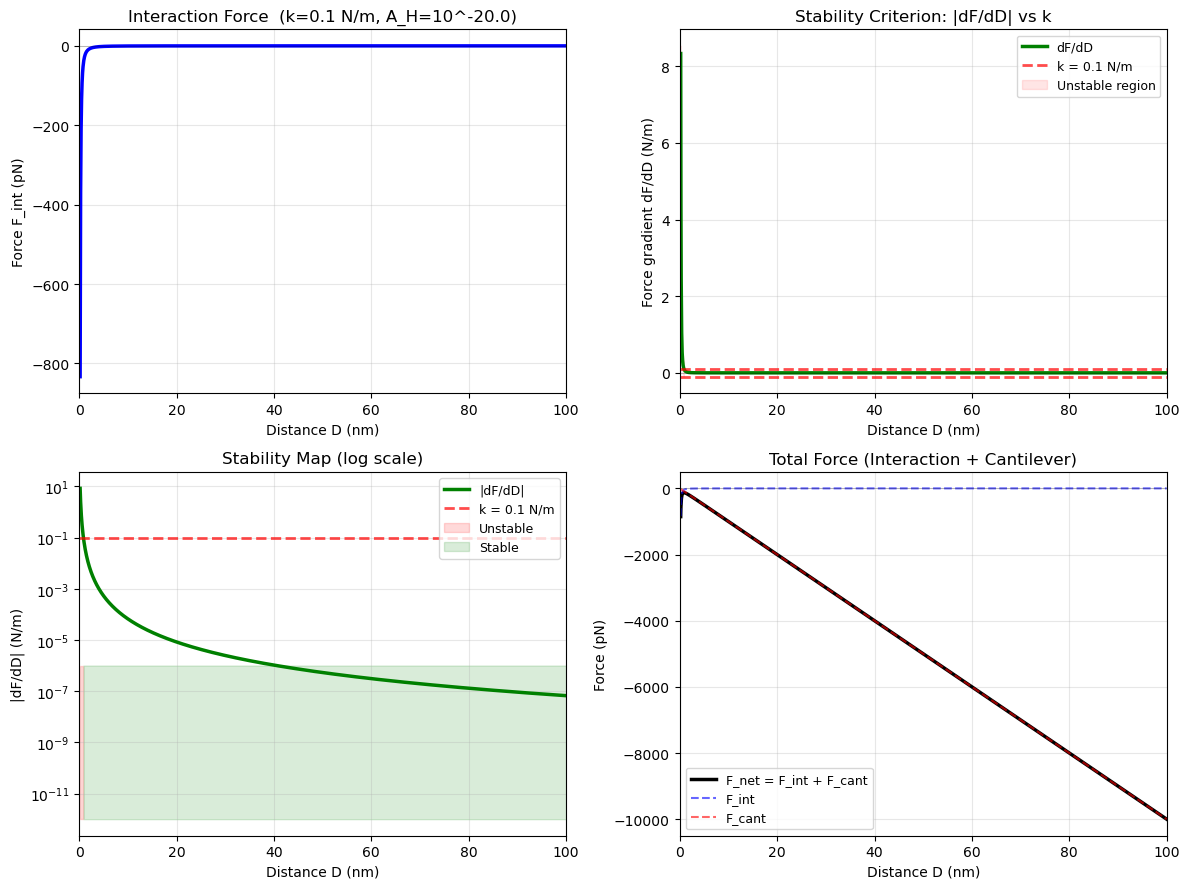

interactive(children=(FloatLogSlider(value=0.1, description='k (N/m)', max=1.0, min=-2.0, step=0.2, style=Slid…

In [9]:
def interactive_jump_to_contact(k_Nm=0.1, A_H_exp=-20, R_nm=20, interaction_type='vdW'):
    '''
    Analyze stability of approach curve.
    interaction_type: 'vdW' or 'LJ'
    '''
    k = k_Nm
    A_H = 10**A_H_exp
    R_m = R_nm * 1e-9
    
    # Distance range
    D_nm = np.linspace(0.2, 100, 2000)
    D_m = D_nm * 1e-9
    
    if interaction_type == 'vdW':
        # van der Waals sphere-plane
        F_int = -A_H * R_m / (6 * D_m**2)  # attractive
        dF_dD = 2 * A_H * R_m / (6 * D_m**3)  # positive = destabilizing
    else:  # LJ approximation at longer range
        epsilon_J = 1e-3 * e_0  # 1 meV
        sigma_m = 0.3e-9
        # Use long-range form for demonstration
        F_int = -24 * epsilon_J * (sigma_m/D_m)**6 / D_m
        dF_dD = np.gradient(F_int, D_m)
    
    F_cant = -k * D_m  # Cantilever restoring force (simplified)
    
    # Stability criterion: |dF/dD| vs k
    abs_dF_dD = np.abs(dF_dD)
    
    print(f"  Jump-to-Contact Stability Analysis")
    print(f"  ──────────────────────────────────")
    print(f"  Cantilever stiffness  k = {k_Nm:.3f} N/m")
    print(f"  Interaction type        = {interaction_type}")
    if interaction_type == 'vdW':
        print(f"  Hamaker constant    A_H = 10^{A_H_exp:.1f} J")
    print(f"  Tip radius              R = {R_nm:.1f} nm")
    print()
    
    # Find maximum |dF/dD|
    max_dF_idx = np.argmax(abs_dF_dD)
    max_dF = abs_dF_dD[max_dF_idx]
    D_max_dF = D_nm[max_dF_idx]
    
    print(f"  Maximum |dF/dD|  = {max_dF:.3e} N/m  at D = {D_max_dF:.2f} nm")
    print(f"  Stability criterion: |dF/dD| < k")
    print()
    
    if max_dF > k:
        print(f"  ⚠ UNSTABLE: |dF/dD|_max ({max_dF:.2e}) > k ({k:.2e})")
        print(f"    → JUMP-TO-CONTACT will occur")
        unstable_region = D_nm[abs_dF_dD > k]
        if len(unstable_region) > 0:
            D_jump_start = unstable_region[-1]  # last point still stable
            D_jump_end = unstable_region[0]      # first point unstable
            print(f"    → Jump occurs between D ≈ {D_jump_end:.2f} and {D_jump_start:.2f} nm")
    else:
        print(f"  ✓ STABLE: |dF/dD|_max ({max_dF:.2e}) < k ({k:.2e})")
        print(f"    → Approach is continuous, no jump")
    print()
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    
    # (a) Interaction force
    ax = axes[0, 0]
    ax.plot(D_nm, F_int*1e12, 'b-', lw=2.5)
    ax.axhline(0, color='k', lw=0.5, alpha=0.3)
    ax.set_xlabel("Distance D (nm)")
    ax.set_ylabel("Force F_int (pN)")
    ax.set_title(f"Interaction Force  (k={k_Nm} N/m, A_H=10^{A_H_exp})")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 100)
    
    # (b) Force gradient
    ax = axes[0, 1]
    ax.plot(D_nm, dF_dD, 'g-', lw=2.5, label='dF/dD')
    ax.axhline(k, color='r', ls='--', lw=2, alpha=0.7, label=f'k = {k_Nm} N/m')
    ax.axhline(-k, color='r', ls='--', lw=2, alpha=0.7)
    ax.axhline(0, color='k', lw=0.5, alpha=0.3)
    
    # Shade unstable region
    unstable = abs_dF_dD > k
    ax.fill_between(D_nm[unstable], dF_dD[unstable]-k*2, dF_dD[unstable]+k*2,
                     color='red', alpha=0.1, label='Unstable region')
    
    ax.set_xlabel("Distance D (nm)")
    ax.set_ylabel("Force gradient dF/dD (N/m)")
    ax.set_title("Stability Criterion: |dF/dD| vs k")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 100)
    
    # (c) Stability map
    ax = axes[1, 0]
    ax.semilogy(D_nm, abs_dF_dD, 'g-', lw=2.5, label='|dF/dD|')
    ax.axhline(k, color='r', ls='--', lw=2, alpha=0.7, label=f'k = {k_Nm} N/m')
    ax.fill_between(D_nm[unstable], 1e-12, 1e-6, color='red', alpha=0.15, label='Unstable')
    ax.fill_between(D_nm[~unstable], 1e-12, 1e-6, color='green', alpha=0.15, label='Stable')
    ax.set_xlabel("Distance D (nm)")
    ax.set_ylabel("|dF/dD| (N/m)")
    ax.set_title("Stability Map (log scale)")
    ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.3)
    ax.set_xlim(0, 100)
    
    # (d) Phase portrait-like plot
    ax = axes[1, 1]
    F_net = F_int + F_cant
    ax.plot(D_nm, F_net*1e12, 'k-', lw=2.5, label='F_net = F_int + F_cant')
    ax.plot(D_nm, F_int*1e12, 'b--', lw=1.5, alpha=0.6, label='F_int')
    ax.plot(D_nm, F_cant*1e12, 'r--', lw=1.5, alpha=0.6, label='F_cant')
    ax.axhline(0, color='k', lw=0.5, alpha=0.3)
    ax.set_xlabel("Distance D (nm)")
    ax.set_ylabel("Force (pN)")
    ax.set_title("Total Force (Interaction + Cantilever)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 100)
    
    plt.tight_layout()
    plt.show()

_ = interact(
    interactive_jump_to_contact,
    k_Nm=FloatLogSlider(value=0.1, base=10, min=-2, max=1, step=0.2,
                        description='k (N/m)', style={'description_width': 'initial'}),
    A_H_exp=FloatSlider(value=-20, min=-22, max=-18, step=0.5,
                        description='log₁₀(A_H)', style={'description_width': 'initial'}),
    R_nm=FloatSlider(value=20, min=5, max=100, step=5,
                     description='R (nm)', style={'description_width': 'initial'}),
    interaction_type=Dropdown(options=['vdW', 'LJ'], value='vdW',
                              description='Interaction:', style={'description_width': 'initial'})
)

---
## 7. Contact Mechanics: Hertz, JKR & DMT Models

When the tip is in **contact** with the sample (D ≤ 0), the deformation is described by contact mechanics models.

### Hertz Model (elastic, frictionless, non-adhesive)

$$F = \frac{4}{3} E^* \sqrt{R} \, \delta^{3/2}$$

where $\delta$ is the indentation depth.

**Valid for:** Hard materials, weak adhesion, small deformations.

### JKR Model (Johnson, Kendall, Roberts)

Includes adhesion work **W**:

$$F = \frac{4}{3} E^* \sqrt{R} \, \delta^{3/2} - 3\pi R W$$

Pull-off force: $F_\text{pull-off} = -\frac{3}{2}\pi R W$

**Valid for:** Soft materials, strong adhesion, large deformations.

### DMT Model (Derjaguin, Muller, Toporov)

Adhesion acts *outside* the contact area:

$$F = \frac{4}{3} E^* \sqrt{R} \, \delta^{3/2} - 2\pi R W$$

Pull-off force: $F_\text{pull-off} = -2\pi R W$

**Valid for:** Hard materials, moderate adhesion.

### Tabor Parameter

The **Tabor parameter** decides which model applies:

$$\mu = \left( \frac{R W^2}{E^{*2} z_0^3} \right)^{1/3}$$

where $z_0 \approx 0.1$ nm is an atomic length scale.

**Classification:**
- μ >> 1 → **JKR regime** (soft materials)
- μ << 1 → **DMT regime** (hard materials)
- μ ≈ 1 → **Transition regime**

**Reference:** Section §2.5, Table 2.4 in textbook.

  Contact Mechanics: Hertz, JKR, DMT Comparison
  ──────────────────────────────────────────────
  Reduced modulus    E* = 10.0 GPa
  Tip radius          R = 20.0 nm
  Adhesion work       W = 100.0 mJ/m²
  Atomic length scale z₀ = 0.10 nm

  Tabor parameter     μ = 12599.210

  → JKR regime (soft materials)

  Pull-off forces:
  ─────────────────
  Hertz (no adhesion):  F_po = 0 (no adhesion)
  JKR:                  F_po = -9424777.961 nN
  DMT:                  F_po = -12566370.614 nN
  Difference:           ΔF = 3141592.654 nN



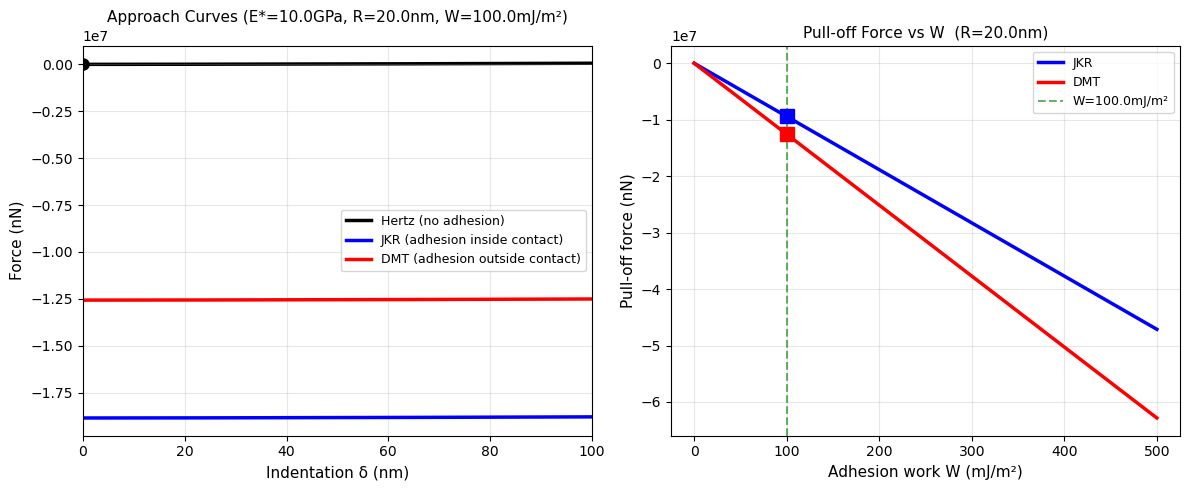

interactive(children=(FloatLogSlider(value=10.0, description='E* (GPa)', max=3.0, min=-3.0, step=0.5, style=Sl…

In [10]:
def interactive_contact_models(E_star_GPa=10, R_nm=20, W_adh=100, z0_nm=0.1):
    '''
    Compare Hertz, JKR, and DMT models.
    E_star_GPa: reduced modulus in GPa
    R_nm: tip radius in nm
    W_adh: adhesion work in mJ/m²
    z0_nm: atomic length scale in nm (typically ~0.1 nm)
    '''
    E_star = E_star_GPa * 1e9  # Pa
    R_m = R_nm * 1e-9
    W = W_adh * 1e3  # mJ/m² to J/m²
    z0_m = z0_nm * 1e-9
    
    # Compute Tabor parameter
    mu = ((R_m * W**2) / (E_star**2 * z0_m**3))**(1/3)
    
    # Indentation range
    delta_nm = np.linspace(0, 100, 500)
    delta_m = delta_nm * 1e-9
    
    # Hertz force
    F_hertz = (4/3) * E_star * np.sqrt(R_m) * delta_m**1.5
    
    # JKR force
    F_jkr = (4/3) * E_star * np.sqrt(R_m) * delta_m**1.5 - 3 * np.pi * R_m * W
    
    # DMT force
    F_dmt = (4/3) * E_star * np.sqrt(R_m) * delta_m**1.5 - 2 * np.pi * R_m * W
    
    # Pull-off forces
    F_pulloff_jkr = -1.5 * np.pi * R_m * W
    F_pulloff_dmt = -2.0 * np.pi * R_m * W
    
    print(f"  Contact Mechanics: Hertz, JKR, DMT Comparison")
    print(f"  ──────────────────────────────────────────────")
    print(f"  Reduced modulus    E* = {E_star_GPa:.1f} GPa")
    print(f"  Tip radius          R = {R_nm:.1f} nm")
    print(f"  Adhesion work       W = {W_adh:.1f} mJ/m²")
    print(f"  Atomic length scale z₀ = {z0_nm:.2f} nm")
    print()
    print(f"  Tabor parameter     μ = {mu:.3f}")
    print()
    
    if mu > 5:
        regime = "JKR regime (soft materials)"
    elif mu < 0.3:
        regime = "DMT regime (hard materials)"
    else:
        regime = "Transition regime"
    print(f"  → {regime}")
    print()
    
    print(f"  Pull-off forces:")
    print(f"  ─────────────────")
    print(f"  Hertz (no adhesion):  F_po = 0 (no adhesion)")
    print(f"  JKR:                  F_po = {F_pulloff_jkr*1e9:.3f} nN")
    print(f"  DMT:                  F_po = {F_pulloff_dmt*1e9:.3f} nN")
    print(f"  Difference:           ΔF = {abs(F_pulloff_jkr - F_pulloff_dmt)*1e9:.3f} nN")
    print()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Approach curve (F vs δ)
    ax = axes[0]
    ax.plot(delta_nm, F_hertz*1e9, 'k-', lw=2.5, label='Hertz (no adhesion)')
    ax.plot(delta_nm, F_jkr*1e9, 'b-', lw=2.5, label='JKR (adhesion inside contact)')
    ax.plot(delta_nm, F_dmt*1e9, 'r-', lw=2.5, label='DMT (adhesion outside contact)')
    
    ax.axhline(0, color='gray', lw=0.5, alpha=0.5)
    ax.plot(0, 0, 'ko', ms=8, zorder=5)
    
    ax.set_xlabel("Indentation δ (nm)", fontsize=11)
    ax.set_ylabel("Force (nN)", fontsize=11)
    ax.set_title(f"Approach Curves (E*={E_star_GPa}GPa, R={R_nm}nm, W={W_adh}mJ/m²)", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 100)
    
    # Pull-off comparison (as function of W)
    W_range = np.linspace(0, 500, 200) * 1e3  # mJ/m² to J/m²
    F_po_jkr_range = -1.5 * np.pi * R_m * W_range
    F_po_dmt_range = -2.0 * np.pi * R_m * W_range
    
    ax = axes[1]
    ax.plot(W_range*1e-3, F_po_jkr_range*1e9, 'b-', lw=2.5, label='JKR')
    ax.plot(W_range*1e-3, F_po_dmt_range*1e9, 'r-', lw=2.5, label='DMT')
    ax.axvline(W_adh, color='g', ls='--', alpha=0.6, label=f'W={W_adh}mJ/m²')
    ax.plot(W_adh, F_pulloff_jkr*1e9, 'bs', ms=10, zorder=5)
    ax.plot(W_adh, F_pulloff_dmt*1e9, 'rs', ms=10, zorder=5)
    
    ax.set_xlabel("Adhesion work W (mJ/m²)", fontsize=11)
    ax.set_ylabel("Pull-off force (nN)", fontsize=11)
    ax.set_title(f"Pull-off Force vs W  (R={R_nm}nm)", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

_ = interact(
    interactive_contact_models,
    E_star_GPa=FloatLogSlider(value=10, base=10, min=-3, max=3, step=0.5,
                              description='E* (GPa)', style={'description_width': 'initial'}),
    R_nm=FloatSlider(value=20, min=5, max=100, step=5,
                     description='R (nm)', style={'description_width': 'initial'}),
    W_adh=FloatLogSlider(value=100, base=10, min=0, max=3, step=0.5,
                         description='W (mJ/m²)', style={'description_width': 'initial'}),
    z0_nm=FloatSlider(value=0.1, min=0.05, max=1, step=0.05,
                      description='z₀ (nm)', style={'description_width': 'initial'})
)

---
## 8. Tabor Parameter — Classification of Materials

The **Tabor parameter** is the key predictor of which contact model (JKR vs DMT) applies:

$$\mu = \left( \frac{R W^2}{E^{*2} z_0^3} \right)^{1/3}$$

Use this interactive tool to classify your material combination:

  ╔══════════════════════════════════════════╗
  ║       TABOR PARAMETER CLASSIFIER         ║
  ╠══════════════════════════════════════════╣
  ║  E* =     1.00 GPa
  ║  R  =     50.0 nm
  ║  W  =    100.0 mJ/m²
  ║  z₀ =    0.100 nm
  ║
  ║  Tabor parameter: μ = 79370.0526
  ╚══════════════════════════════════════════╝

  Regime Classification: JKR (Soft materials)
  Adhesion acts within the contact area.
Deformation is significant.

  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Typical Material Examples:
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Glass on glass             μ=1709.976  →  JKR
  Polystyrene bead           μ=7663.094  →  JKR
  Cell on substrate          μ=430886.938  →  JKR
  Gold on gold (water)       μ=2693.043  →  JKR



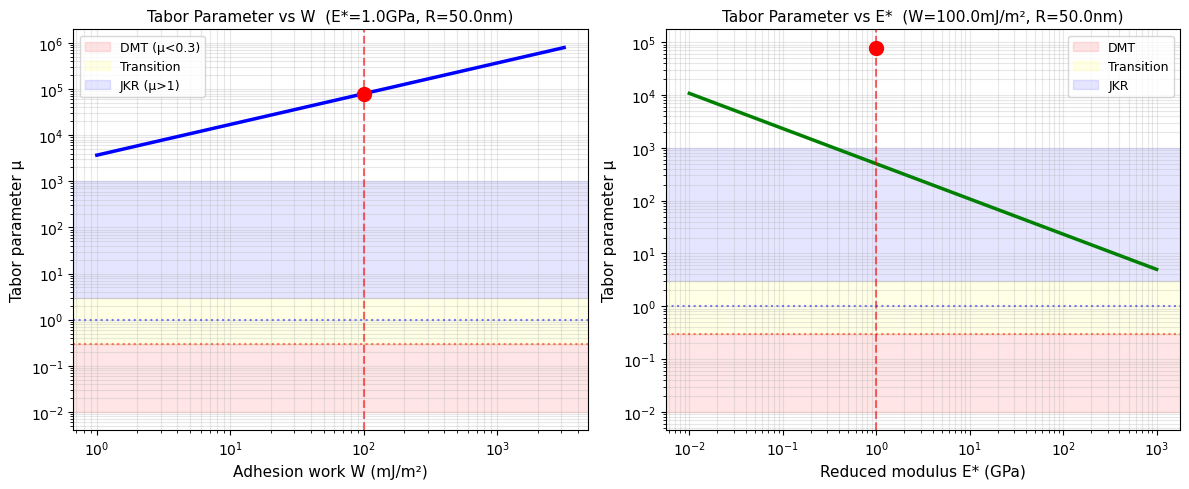

interactive(children=(FloatLogSlider(value=1.0, description='E* (GPa)', max=3.0, min=-2.0, step=0.5, style=Sli…

In [11]:
def tabor_classifier(E_star_GPa=1, R_nm=50, W_mJ_m2=100, z0_nm=0.1):
    E_star = E_star_GPa * 1e9
    R_m = R_nm * 1e-9
    W = W_mJ_m2 * 1e3
    z0_m = z0_nm * 1e-9
    
    mu = ((R_m * W**2) / (E_star**2 * z0_m**3))**(1/3)
    
    # Compute some key lengths
    contact_radius_nm = np.nan  # Would need δ to compute properly
    
    print(f"  ╔══════════════════════════════════════════╗")
    print(f"  ║       TABOR PARAMETER CLASSIFIER         ║")
    print(f"  ╠══════════════════════════════════════════╣")
    print(f"  ║  E* = {E_star_GPa:8.2f} GPa")
    print(f"  ║  R  = {R_nm:8.1f} nm")
    print(f"  ║  W  = {W_mJ_m2:8.1f} mJ/m²")
    print(f"  ║  z₀ = {z0_nm:8.3f} nm")
    print(f"  ║")
    print(f"  ║  Tabor parameter: μ = {mu:.4f}")
    print(f"  ╚══════════════════════════════════════════╝")
    print()
    
    if mu > 1:
        regime = "JKR (Soft materials)"
        color_code = "✓ JKR"
        explanation = "Adhesion acts within the contact area.\nDeformation is significant."
    elif mu < 0.3:
        regime = "DMT (Hard materials)"
        color_code = "✓ DMT"
        explanation = "Adhesion acts outside the contact area.\nMinimal deformation."
    else:
        regime = "TRANSITION (μ ≈ 0.5–1)"
        color_code = "⚠ TRANSITION"
        explanation = "Neither model applies well.\nNeed intermediate theory."
    
    print(f"  Regime Classification: {regime}")
    print(f"  {explanation}")
    print()
    
    # Material examples table
    print(f"  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print(f"  Typical Material Examples:")
    print(f"  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    
    materials = [
        ("Glass on glass",  100, 20, 50, 0.1),
        ("Polystyrene bead", 10, 50, 30, 0.1),
        ("Cell on substrate", 0.05, 20, 100, 0.1),
        ("Gold on gold (water)", 80, 50, 50, 0.1),
    ]
    
    for name, E, R, W, z0 in materials:
        mu_test = ((R*1e-9 * (W*1e3)**2) / ((E*1e9)**2 * (z0*1e-9)**3))**(1/3)
        if mu_test > 1:
            regime_test = "JKR"
        elif mu_test < 0.3:
            regime_test = "DMT"
        else:
            regime_test = "Transition"
        print(f"  {name:25s}  μ={mu_test:6.3f}  →  {regime_test}")
    
    print()
    
    # Plot tabor parameter map
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Vary W (horizontal)
    W_range = np.logspace(0, 3.5, 100) * 1e3  # mJ/m² to J/m²
    mu_vs_W = ((R_m * W_range**2) / (E_star**2 * z0_m**3))**(1/3)
    
    ax1.loglog(W_range*1e-3, mu_vs_W, 'b-', lw=2.5)
    ax1.axvline(W_mJ_m2, color='r', ls='--', alpha=0.6)
    ax1.plot(W_mJ_m2, mu, 'ro', ms=10, zorder=5)
    
    ax1.axhspan(1e-2, 0.3, color='red', alpha=0.1, label='DMT (μ<0.3)')
    ax1.axhspan(0.3, 3, color='yellow', alpha=0.1, label='Transition')
    ax1.axhspan(3, 1e3, color='blue', alpha=0.1, label='JKR (μ>1)')
    ax1.axhline(0.3, color='red', ls=':', alpha=0.5)
    ax1.axhline(1.0, color='blue', ls=':', alpha=0.5)
    
    ax1.set_xlabel("Adhesion work W (mJ/m²)", fontsize=11)
    ax1.set_ylabel("Tabor parameter μ", fontsize=11)
    ax1.set_title(f"Tabor Parameter vs W  (E*={E_star_GPa}GPa, R={R_nm}nm)", fontsize=11)
    ax1.legend(fontsize=9)
    ax1.grid(True, which='both', alpha=0.3)
    
    # Vary E* (horizontal)
    E_range = np.logspace(-2, 3, 100) * 1e9  # GPa to Pa
    mu_vs_E = ((R_m * W**2) / (E_range**2 * z0_m**3))**(1/3)
    
    ax2.loglog(E_range*1e-9, mu_vs_E, 'g-', lw=2.5)
    ax2.axvline(E_star_GPa, color='r', ls='--', alpha=0.6)
    ax2.plot(E_star_GPa, mu, 'ro', ms=10, zorder=5)
    
    ax2.axhspan(1e-2, 0.3, color='red', alpha=0.1, label='DMT')
    ax2.axhspan(0.3, 3, color='yellow', alpha=0.1, label='Transition')
    ax2.axhspan(3, 1e3, color='blue', alpha=0.1, label='JKR')
    ax2.axhline(0.3, color='red', ls=':', alpha=0.5)
    ax2.axhline(1.0, color='blue', ls=':', alpha=0.5)
    
    ax2.set_xlabel("Reduced modulus E* (GPa)", fontsize=11)
    ax2.set_ylabel("Tabor parameter μ", fontsize=11)
    ax2.set_title(f"Tabor Parameter vs E*  (W={W_mJ_m2}mJ/m², R={R_nm}nm)", fontsize=11)
    ax2.legend(fontsize=9)
    ax2.grid(True, which='both', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

_ = interact(
    tabor_classifier,
    E_star_GPa=FloatLogSlider(value=1, base=10, min=-2, max=3, step=0.5,
                              description='E* (GPa)', style={'description_width': 'initial'}),
    R_nm=FloatLogSlider(value=50, base=10, min=0, max=2, step=0.5,
                        description='R (nm)', style={'description_width': 'initial'}),
    W_mJ_m2=FloatLogSlider(value=100, base=10, min=-1, max=3, step=0.5,
                           description='W (mJ/m²)', style={'description_width': 'initial'}),
    z0_nm=FloatSlider(value=0.1, min=0.05, max=1, step=0.05,
                      description='z₀ (nm)', style={'description_width': 'initial'})
)

---
## 9. Complete Force–Distance Curve Simulation

Now we combine all the physics: van der Waals interactions, contact mechanics, adhesion, and cantilever dynamics to simulate a **realistic AFM force–distance curve**.

The simulation includes:
1. **Approach phase**: Tip approaches sample
2. **Contact phase**: Hertz/JKR mechanics apply
3. **Retraction phase**: Adhesion hysteresis (pull-off)

**Model assumptions:**
- Sphere-plane geometry (tip radius R)
- Reduced modulus E*
- Work of adhesion W
- Cantilever stiffness k
- Simple viscoelastic damping (hysteresis)

**Simulation steps:**
1. Define interaction force: F_int(D) = vdW + contact
2. Solve cantilever equilibrium: F_int + F_cant = 0
3. Track approach and retraction separately
4. Extract key observables: jump-in distance, contact force, pull-off force, dissipated energy

  ╔═══════════════════════════════════════════════╗
  ║     FORCE–DISTANCE SIMULATION RESULTS         ║
  ╠═══════════════════════════════════════════════╣
  ║  k = 0.200 N/m    E* = 1.00e+09 Pa
  ║  R = 20 nm        W = 50 mJ/m²
  ║  Model: DMT      Hysteresis: 2.0 nN
  ╠═══════════════════════════════════════════════╣
  ║  Pull-off force : -1.28 nN
  ║  Dissipated energy: 1.727e-16 J
  ╚═══════════════════════════════════════════════╝


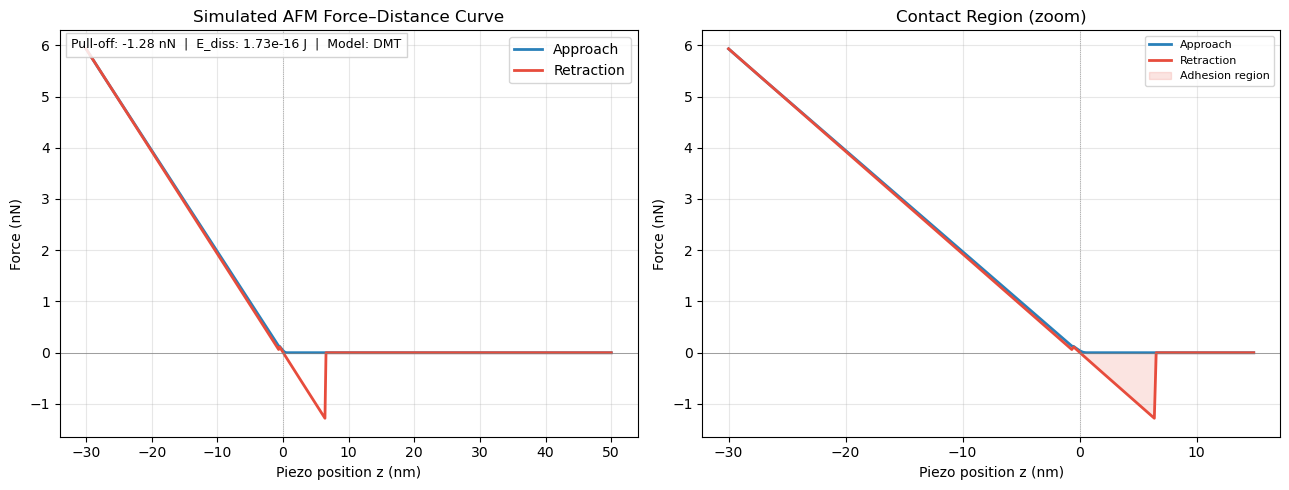

interactive(children=(FloatLogSlider(value=0.2, description='k (N/m)', max=1.6, min=-2.0, readout_format='.3f'…

In [12]:
from scipy.optimize import brentq
import warnings
warnings.filterwarnings('ignore')

# ── Physical interaction models ──────────────────────────────────────

def lennard_jones_force(r, epsilon, sigma):
    """Compute LJ force using ratio form (avoids overflow for small r)."""
    r = np.maximum(r, 0.5 * sigma)
    sr = sigma / r
    sr6 = sr**6
    return (24.0 * epsilon / r) * (2.0 * sr6 * sr6 - sr6)

def hertz_force(delta, E_star, R):
    delta = np.maximum(delta, 0.0)
    return (4.0/3.0) * E_star * np.sqrt(R) * delta**1.5

def adhesive_offset(R, Wadh, model="DMT"):
    C = 2.0 if model.upper() == "DMT" else 1.5
    return -C * np.pi * R * Wadh

# ── Piecewise force: LJ for D >= 0, Hertz+adhesion for D < 0 ────────

def F_noncontact(D, params):
    r = D + params["r0"]
    return lennard_jones_force(r, params["epsilon"], params["sigma"])

def F_contact(D, params, branch="approach"):
    delta = -D
    F_H = hertz_force(delta, params["E_star"], params["R"])
    F_adh_full = adhesive_offset(params["R"], params["Wadh"], model=params["adh_model"])
    delta_ref = params["sigma"]
    adh_scale = min(delta / delta_ref, 1.0) if delta > 0 else 0.0
    F_adh = F_adh_full * adh_scale
    if branch == "retract":
        F_hyst = -params["hyst_strength"] * np.tanh(delta / params["hyst_delta0"])
    else:
        F_hyst = 0.0
    return F_H + F_adh + F_hyst

def total_interaction_force(D, params, branch="approach"):
    if D >= 0:
        return F_noncontact(D, params)
    else:
        return F_contact(D, params, branch)

# ── Coupled cantilever solver (exact root-finding) ──────────────────

def simulate_fd_curve(params, z_min=-30e-9, z_max=50e-9, n=500):
    """
    Simulate an AFM force–distance curve using exact root-finding.
    Equilibrium: g(D) = F_int(D) + k·D − k·z = 0
    Solved separately in non-contact (D > 0) and contact (D < 0) regimes.
    """
    k = params["k"]
    z_approach = np.linspace(z_max, z_min, n)
    z_retract  = np.linspace(z_min, z_max, n)

    def _find_roots(func, D_lo, D_hi, z, extra_args=(), n_scan=300):
        if D_lo >= D_hi:
            return []
        D_scan = np.linspace(D_lo, D_hi, n_scan)
        g_scan = np.array([func(d, z, *extra_args) for d in D_scan])
        roots = []
        for idx in np.where(np.diff(np.sign(g_scan)))[0]:
            if np.isfinite(g_scan[idx]) and np.isfinite(g_scan[idx + 1]):
                try:
                    roots.append(
                        brentq(func, D_scan[idx], D_scan[idx + 1],
                               args=(z, *extra_args), xtol=1e-14, maxiter=100))
                except (ValueError, RuntimeError):
                    pass
        return sorted(roots)

    def g_nc(D, z):
        return F_noncontact(D, params) + k * D - k * z
    def g_c(D, z, branch_name):
        return F_contact(D, params, branch_name) + k * D - k * z

    def _solve(z_array, branch_name, D0):
        D_prev = D0
        on_primary = True
        is_approach = (branch_name == "approach")
        D_out, F_out = [], []

        for z in z_array:
            D_hi = max(z + 5e-9, z_max + 5e-9)
            if is_approach:
                prim_func, prim_range = g_nc, (1e-12, D_hi)
                sec_func,  sec_range  = g_c,  (-30e-9, -1e-12)
                prim_args, sec_args   = (), ("approach",)
            else:
                prim_func, prim_range = g_c,  (-30e-9, -1e-12)
                sec_func,  sec_range  = g_nc, (1e-12, D_hi)
                prim_args, sec_args   = ("retract",), ()

            if on_primary:
                hw = 3e-9
                cen = np.clip(D_prev, prim_range[0]+1e-12, prim_range[1]-1e-12)
                lo_n = max(cen - hw, prim_range[0])
                hi_n = min(cen + hw, prim_range[1])
                roots = _find_roots(prim_func, lo_n, hi_n, z, prim_args)
                if not roots:
                    roots = _find_roots(prim_func, prim_range[0], prim_range[1], z, prim_args)
                if roots:
                    dists = [abs(r - D_prev) for r in roots]
                    D_sol = roots[np.argmin(dists)]
                else:
                    on_primary = False
                    roots = _find_roots(sec_func, sec_range[0], sec_range[1], z, sec_args)
                    D_sol = (roots[-1] if is_approach else roots[0]) if roots else D_prev
            else:
                hw = 3e-9
                cen = np.clip(D_prev, sec_range[0]+1e-12, sec_range[1]-1e-12)
                lo_n = max(cen - hw, sec_range[0])
                hi_n = min(cen + hw, sec_range[1])
                roots = _find_roots(sec_func, lo_n, hi_n, z, sec_args)
                if not roots:
                    roots = _find_roots(sec_func, sec_range[0], sec_range[1], z, sec_args)
                if roots:
                    dists = [abs(r - D_prev) for r in roots]
                    D_sol = roots[np.argmin(dists)]
                else:
                    D_sol = D_prev

            D_out.append(D_sol)
            F_out.append(k * (D_sol - z))
            D_prev = D_sol

        return z_array, np.array(D_out), np.array(F_out), D_prev

    z_a, D_app, F_app, D_last = _solve(z_approach, "approach", z_approach[0])
    z_r, D_ret, F_ret, _      = _solve(z_retract, "retract",  D_last)
    return (z_a, F_app), (z_r, F_ret)

# ── Interactive F–D simulation with sliders ──────────────────────────

def interactive_fd_curve(k_Nm=0.2, E_star_Pa=1e9, R_nm=20, W_adh_mJ=50,
                         hyst_nN=2.0, adh_model="DMT"):
    p = dict(
        k=k_Nm,
        epsilon=2e-20, sigma=0.35e-9, r0=0.35e-9,
        E_star=E_star_Pa,
        R=R_nm * 1e-9,
        Wadh=W_adh_mJ * 1e-3,
        adh_model=adh_model,
        hyst_strength=hyst_nN * 1e-9,
        hyst_delta0=2e-9,
    )

    (z_a, F_a), (z_r, F_r) = simulate_fd_curve(p, n=500)

    pull_off = np.min(F_r) * 1e9
    E_app = np.trapz(F_a, z_a)
    E_ret = np.trapz(F_r, z_r)
    E_diss = abs(E_ret - E_app)

    print(f"  ╔═══════════════════════════════════════════════╗")
    print(f"  ║     FORCE–DISTANCE SIMULATION RESULTS         ║")
    print(f"  ╠═══════════════════════════════════════════════╣")
    print(f"  ║  k = {k_Nm:.3f} N/m    E* = {E_star_Pa:.2e} Pa")
    print(f"  ║  R = {R_nm:.0f} nm        W = {W_adh_mJ:.0f} mJ/m²")
    print(f"  ║  Model: {adh_model}      Hysteresis: {hyst_nN:.1f} nN")
    print(f"  ╠═══════════════════════════════════════════════╣")
    print(f"  ║  Pull-off force : {pull_off:.2f} nN")
    print(f"  ║  Dissipated energy: {E_diss:.3e} J")
    print(f"  ╚═══════════════════════════════════════════════╝")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    ax.plot(z_a * 1e9, F_a * 1e9, color="#2980B9", lw=2, label="Approach")
    ax.plot(z_r * 1e9, F_r * 1e9, color="#E74C3C", lw=2, label="Retraction")
    ax.axhline(0, color="grey", lw=0.5)
    ax.axvline(0, color="grey", lw=0.5, ls=":")
    ax.set_xlabel("Piezo position z (nm)")
    ax.set_ylabel("Force (nN)")
    ax.set_title("Simulated AFM Force–Distance Curve")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

    info = (f"Pull-off: {pull_off:.2f} nN  |  "
            f"E_diss: {E_diss:.2e} J  |  "
            f"Model: {adh_model}")
    ax.text(0.02, 0.98, info, transform=ax.transAxes,
            fontsize=9, ha="left", va="top",
            bbox=dict(facecolor="white", edgecolor="#ccc", alpha=0.85))

    # Zoom into contact region
    ax2 = axes[1]
    mask_a = z_a * 1e9 < 15
    mask_r = z_r * 1e9 < 15
    ax2.plot(z_a[mask_a] * 1e9, F_a[mask_a] * 1e9, color="#2980B9", lw=2, label="Approach")
    ax2.plot(z_r[mask_r] * 1e9, F_r[mask_r] * 1e9, color="#E74C3C", lw=2, label="Retraction")
    ax2.fill_between(z_r[mask_r] * 1e9, F_r[mask_r] * 1e9, 0,
                     where=F_r[mask_r] < 0, alpha=0.15, color="#E74C3C", label="Adhesion region")
    ax2.axhline(0, color="grey", lw=0.5)
    ax2.axvline(0, color="grey", lw=0.5, ls=":")
    ax2.set_xlabel("Piezo position z (nm)")
    ax2.set_ylabel("Force (nN)")
    ax2.set_title("Contact Region (zoom)")
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

_ = interact(
    interactive_fd_curve,
    k_Nm=FloatLogSlider(value=0.2, base=10, min=-2, max=1.6, step=0.1,
                        description='k (N/m)', style={'description_width': 'initial'},
                        readout_format='.3f'),
    E_star_Pa=FloatLogSlider(value=1e9, base=10, min=6, max=11, step=0.25,
                             description='E* (Pa)', style={'description_width': 'initial'},
                             readout_format='.2e'),
    R_nm=FloatSlider(value=20, min=2, max=100, step=2,
                     description='R (nm)', style={'description_width': 'initial'}),
    W_adh_mJ=FloatSlider(value=50, min=1, max=500, step=5,
                         description='W_adh (mJ/m²)', style={'description_width': 'initial'}),
    hyst_nN=FloatSlider(value=2.0, min=0, max=10, step=0.5,
                        description='Hysteresis (nN)', style={'description_width': 'initial'}),
    adh_model=Dropdown(options=["DMT", "JKR"], value="DMT",
                       description='Adhesion model', style={'description_width': 'initial'})
)

---
## 10. Loading Rate & Molecular Rupture Forces — Bell-Evans Model

When pulling on a molecular bond, the rupture force depends on **loading rate** (force/time). This is captured by the **Bell-Evans model**:

$$F^* = \frac{k_B T}{x_\beta} \ln\left( \frac{r_F x_\beta}{k_{\text{off}}^0 k_B T} \right)$$

where:
- **r_F** = loading rate (force/time, typically pN/s or nN/s)
- **x_β** = barrier distance (characteristic length, ~0.1–1 nm)
- **k_off⁰** = spontaneous off-rate (s⁻¹, e.g., 1 Hz for typical bonds)

**Key insight (§2.6.3):**
- **Slow loading** (low r_F): rupture at low force, many thermal escape events
- **Fast loading** (high r_F): rupture at high force, fewer thermal escape opportunities
- F* ∝ ln(r_F): logarithmic, so force increases slowly even with huge rate changes

**Typical values:**
- Molecular bonds: F* = 50–500 pN, x_β = 0.1–1 nm
- Loading rates: 0.1–100 nN/s

**Reference:** Section §2.6.3, Figure 2.11 in textbook.

  Bell-Evans Model: Loading Rate Dependence
  ─────────────────────────────────────────
  Loading rate       r_F = 1.000 nN/s
  Barrier distance   x_β = 0.50 nm
  Spontaneous off-rate k_off⁰ = 1.0 Hz
  Temperature         T = 298 K
  ─────────────────────────────────────────
  Rupture force     F* = 39.5 pN
  Thermal energy    k_B T = 0.000×10⁻²¹ J

  Log-argument: ln(r_F·x_β / (k_off⁰·k_B·T)) = ln(1.215e+02) = 4.800



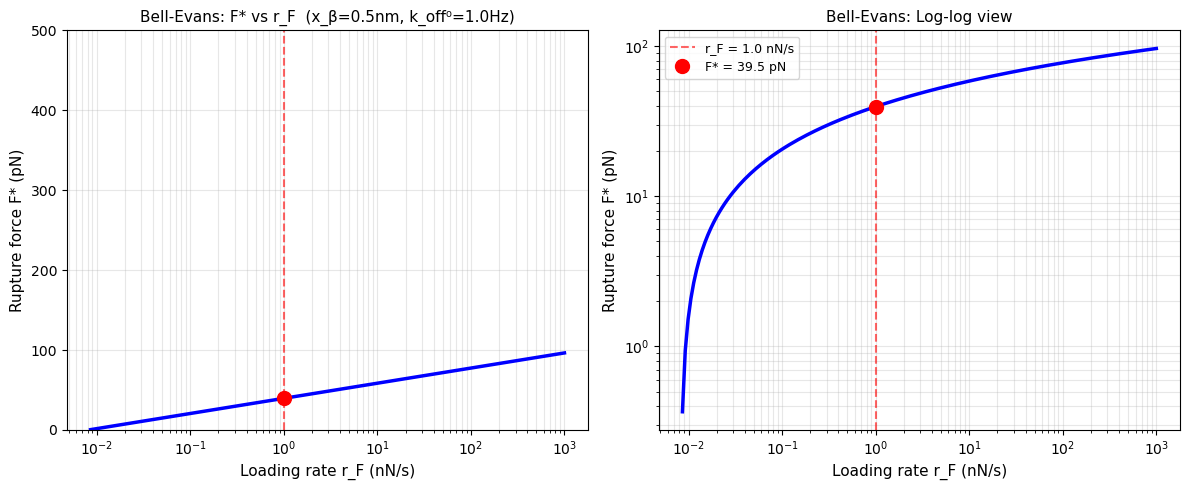

interactive(children=(FloatLogSlider(value=1.0, description='r_F (nN/s)', max=2.0, min=-3.0, step=0.5, style=S…

In [13]:
def interactive_bell_evans(loading_rate_nN_s=1.0, x_beta_nm=0.5, k_off0_Hz=1.0, T_K=298):
    '''
    Bell-Evans model for force-loading-rate dependence
    loading_rate_nN_s: nN/s
    x_beta_nm: barrier distance in nm
    k_off0_Hz: spontaneous off-rate in Hz
    T_K: temperature in K
    '''
    r_F = loading_rate_nN_s * 1e-9 / 1  # nN/s → N/s
    x_beta = x_beta_nm * 1e-9  # nm → m
    k_off0 = k_off0_Hz
    T = T_K
    
    # Bell-Evans rupture force
    F_rupture = (k_B * T / x_beta) * np.log(r_F * x_beta / (k_off0 * k_B * T))
    
    # Ensure F_rupture is positive
    if F_rupture < 0:
        F_rupture = 0.1e-12  # pN
    
    print(f"  Bell-Evans Model: Loading Rate Dependence")
    print(f"  ─────────────────────────────────────────")
    print(f"  Loading rate       r_F = {loading_rate_nN_s:.3f} nN/s")
    print(f"  Barrier distance   x_β = {x_beta_nm:.2f} nm")
    print(f"  Spontaneous off-rate k_off⁰ = {k_off0:.1f} Hz")
    print(f"  Temperature         T = {T_K:.0f} K")
    print(f"  ─────────────────────────────────────────")
    print(f"  Rupture force     F* = {F_rupture*1e12:.1f} pN")
    print(f"  Thermal energy    k_B T = {k_B*T*1e-21:.3f}×10⁻²¹ J")
    print()
    
    # Log analysis
    log_arg = r_F * x_beta / (k_off0 * k_B * T)
    print(f"  Log-argument: ln(r_F·x_β / (k_off⁰·k_B·T)) = ln({log_arg:.3e}) = {np.log(log_arg):.3f}")
    print()
    
    # Plot: F* vs loading rate
    loading_rates_nN_s = np.logspace(-3, 3, 200)  # pN/s to µN/s
    loading_rates_N_s = loading_rates_nN_s * 1e-9
    
    F_ruptures = (k_B * T / x_beta) * np.log(loading_rates_N_s * x_beta / (k_off0 * k_B * T))
    F_ruptures[F_ruptures < 0] = np.nan
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Linear-log
    ax1.semilogx(loading_rates_nN_s, F_ruptures*1e12, 'b-', lw=2.5)
    ax1.axvline(loading_rate_nN_s, color='r', ls='--', alpha=0.6)
    ax1.plot(loading_rate_nN_s, F_rupture*1e12, 'ro', ms=10, zorder=5)
    
    ax1.set_xlabel("Loading rate r_F (nN/s)", fontsize=11)
    ax1.set_ylabel("Rupture force F* (pN)", fontsize=11)
    ax1.set_title(f"Bell-Evans: F* vs r_F  (x_β={x_beta_nm}nm, k_off⁰={k_off0}Hz)", fontsize=11)
    ax1.grid(True, which='both', alpha=0.3)
    ax1.set_ylim(0, 500)
    
    # Log-log
    ax2.loglog(loading_rates_nN_s, F_ruptures*1e12, 'b-', lw=2.5)
    ax2.axvline(loading_rate_nN_s, color='r', ls='--', alpha=0.6, label=f'r_F = {loading_rate_nN_s} nN/s')
    ax2.plot(loading_rate_nN_s, F_rupture*1e12, 'ro', ms=10, zorder=5, label=f'F* = {F_rupture*1e12:.1f} pN')
    
    ax2.set_xlabel("Loading rate r_F (nN/s)", fontsize=11)
    ax2.set_ylabel("Rupture force F* (pN)", fontsize=11)
    ax2.set_title("Bell-Evans: Log-log view", fontsize=11)
    ax2.legend(fontsize=9)
    ax2.grid(True, which='both', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

_ = interact(
    interactive_bell_evans,
    loading_rate_nN_s=FloatLogSlider(value=1.0, base=10, min=-3, max=2, step=0.5,
                                     description='r_F (nN/s)', style={'description_width': 'initial'}),
    x_beta_nm=FloatSlider(value=0.5, min=0.1, max=2, step=0.1,
                          description='x_β (nm)', style={'description_width': 'initial'}),
    k_off0_Hz=FloatLogSlider(value=1.0, base=10, min=-3, max=3, step=1,
                             description='k_off⁰ (Hz)', style={'description_width': 'initial'}),
    T_K=FloatSlider(value=298, min=4, max=350, step=5,
                    description='T (K)', style={'description_width': 'initial'})
)

---
## 11. Parameter Exploration — How Experimental Choices Affect Results

This section explores **parameter sweeps**: how changing k, E*, R, or W affects the approach curves.

**Question (from §2.8.3):** *"How does cantilever stiffness affect the measurable force-distance profile?"*

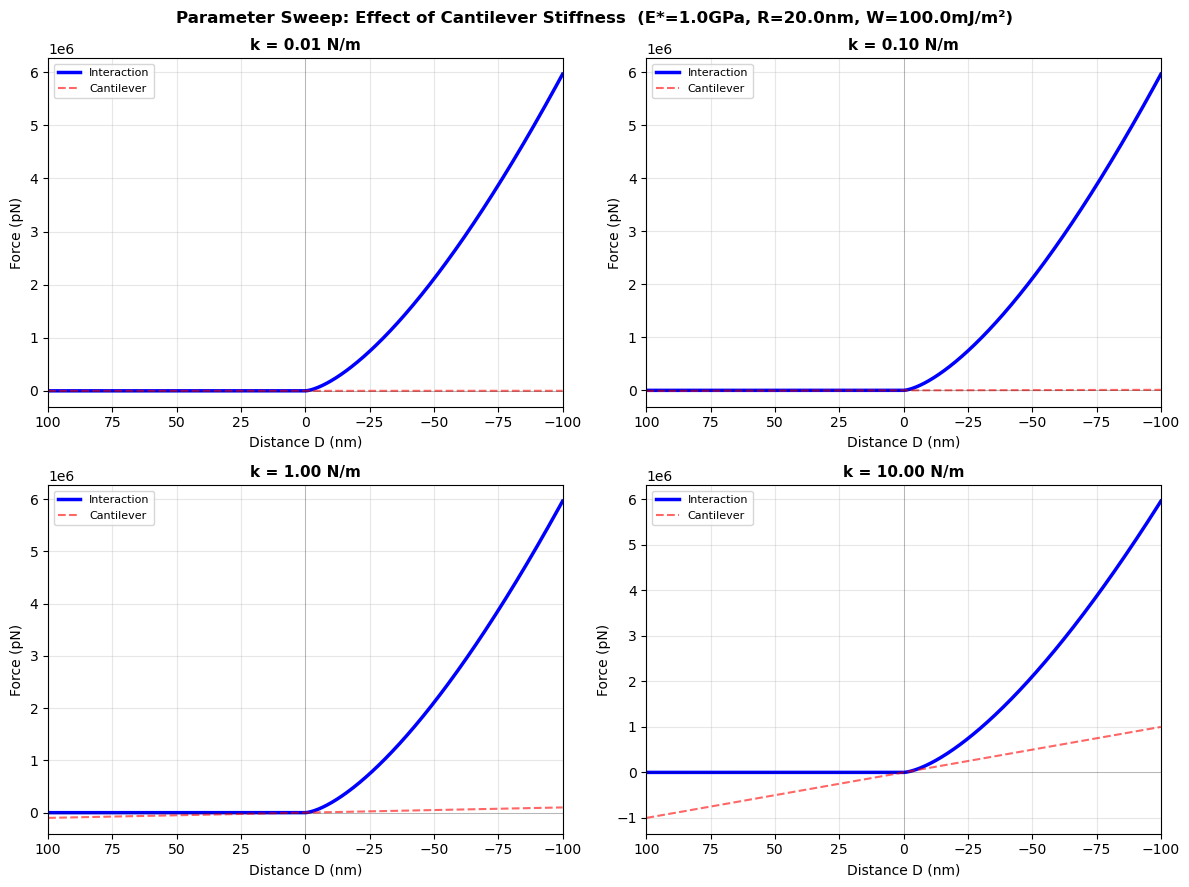


  Effect of Cantilever Stiffness on F–D Curves
  ──────────────────────────────────────────────
  E* = 1.0 GPa,  R = 20.0 nm,  W = 100.0 mJ/m²

  Soft cantilevers (k << 0.1 N/m):
    → Sensitive to small forces
    → Prone to jump-to-contact
    → Large thermal noise

  Stiff cantilevers (k > 1 N/m):
    → Continuous approach curves
    → Low sensitivity to weak interactions
    → Risk of sample damage at high contact forces


interactive(children=(FloatLogSlider(value=1.0, description='E* (GPa)', max=2.0, min=-2.0, step=0.5, style=Sli…

In [14]:
def parameter_sweep_stiffness(E_star_GPa=1, R_nm=20, W_adh_mJ=100, A_H_exp=-20):
    '''
    Compare approach curves for different cantilever stiffnesses
    '''
    E_star = E_star_GPa * 1e9
    R_m = R_nm * 1e-9
    W = W_adh_mJ * 1e3
    A_H = 10**A_H_exp
    
    k_values = [0.01, 0.1, 1.0, 10.0]  # N/m
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.flatten()
    
    for idx, k in enumerate(k_values):
        ax = axes[idx]
        
        # Simple approach: D range, compute F_int directly
        D_range_nm = np.linspace(100, -100, 500)
        D_range_m = D_range_nm * 1e-9
        
        F_int = np.zeros_like(D_range_m)
        for i, D in enumerate(D_range_m):
            if D >= 0:
                # vdW
                F_int[i] = -A_H * R_m / (6 * D**2) if D > 0 else 0
            else:
                # contact
                delta = -D
                F_int[i] = (4/3) * E_star * np.sqrt(R_m) * delta**1.5
        
        ax.plot(D_range_nm, F_int*1e12, 'b-', lw=2.5, label=f'Interaction')
        
        # Equilibrium curve (roughly)
        F_cant = -k * D_range_m
        ax.plot(D_range_nm, F_cant*1e12, 'r--', lw=1.5, alpha=0.6, label='Cantilever')
        
        ax.axhline(0, color='k', lw=0.5, alpha=0.3)
        ax.axvline(0, color='k', lw=0.5, alpha=0.3)
        
        ax.set_xlabel("Distance D (nm)", fontsize=10)
        ax.set_ylabel("Force (pN)", fontsize=10)
        ax.set_title(f"k = {k:.2f} N/m", fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(100, -100)
    
    plt.suptitle(f"Parameter Sweep: Effect of Cantilever Stiffness  (E*={E_star_GPa}GPa, R={R_nm}nm, W={W_adh_mJ}mJ/m²)",
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"\n  Effect of Cantilever Stiffness on F–D Curves")
    print(f"  ──────────────────────────────────────────────")
    print(f"  E* = {E_star_GPa:.1f} GPa,  R = {R_nm:.1f} nm,  W = {W_adh_mJ:.1f} mJ/m²")
    print()
    print(f"  Soft cantilevers (k << 0.1 N/m):")
    print(f"    → Sensitive to small forces")
    print(f"    → Prone to jump-to-contact")
    print(f"    → Large thermal noise")
    print()
    print(f"  Stiff cantilevers (k > 1 N/m):")
    print(f"    → Continuous approach curves")
    print(f"    → Low sensitivity to weak interactions")
    print(f"    → Risk of sample damage at high contact forces")

_ = interact(
    parameter_sweep_stiffness,
    E_star_GPa=FloatLogSlider(value=1, base=10, min=-2, max=2, step=0.5,
                              description='E* (GPa)', style={'description_width': 'initial'}),
    R_nm=FloatSlider(value=20, min=5, max=100, step=5,
                     description='R (nm)', style={'description_width': 'initial'}),
    W_adh_mJ=FloatLogSlider(value=100, base=10, min=0, max=2.5, step=0.5,
                            description='W (mJ/m²)', style={'description_width': 'initial'}),
    A_H_exp=FloatSlider(value=-20, min=-22, max=-18, step=0.5,
                        description='log₁₀(A_H)', style={'description_width': 'initial'})
)

---
## Summary: Key Takeaways from Chapter 2

### 1. **Atomic Interactions** — Lennard-Jones & vdW
- Repulsive r⁻¹² term (overlap) dominates at short range
- Attractive r⁻⁶ term (dipole–dipole) dominates at longer range
- Macroscopic sphere–plane force: F ∝ R / D²

### 2. **Electrostatic Forces & Screening**
- In vacuum: pure Coulomb, ranges to infinity
- In solution: Debye screening, range ~ λ_D
- At 10 mM salt: λ_D ~ 3 nm (strongly screened)

### 3. **DLVO Theory** — vdW + Electrostatics
- Energy barrier in solution: repulsion dominates at D ~ λ_D
- Secondary minimum: where particles stick (weak adhesion)
- Primary minimum: contact region (strong adhesion)

### 4. **Capillary Forces** — Critical in Humidity
- Water bridges in humid air: F_cap >> F_vdW
- Dominates over vdW by 100–1000×
- Highly humidity-dependent

### 5. **Jump-to-Contact** — Mechanical Instability
- Occurs when |dF/dD| > k
- Soft cantilevers jump easily
- Stiff cantilevers remain stable

### 6. **Contact Mechanics** — Hertz, JKR, DMT
- **Tabor parameter μ** predicts which model applies
- μ >> 1: JKR (soft, adhesion inside contact)
- μ << 1: DMT (hard, adhesion outside contact)

### 7. **Hysteresis & Energy Dissipation**
- Approach ≠ Retraction due to viscoelasticity
- Energy loss ~ area enclosed in F-D loop
- Depends on loading rate, tip–sample interaction

### 8. **Loading Rate Effects** — Bell-Evans Model
- Rupture force increases logarithmically with loading rate
- Dynamic force spectroscopy probes kinetic barriers
- Reveals bond lifetime and barrier position

### 9. **Experimental Trade-offs**
| Parameter | Soft Cantilever | Stiff Cantilever |
|---|---|---|
| Force sensitivity | ↑ | ↓ |
| Thermal noise | ↑ | ↓ |
| Jump-to-contact | Likely | Unlikely |
| Spatial resolution | ↑ | ↓ |
| Sample damage risk | ↓ | ↑ |

### 10. **Central Message**
> **Every AFM measurement is a coupled system:**
> - Atomic/molecular interactions
> - Surface thermodynamics (adhesion, capillary)
> - Elastic contact mechanics
> - Cantilever dynamics
> - **No single "best" parameter set** — always optimize for your specific question.

---

## Discussion Questions (from Exercise §2.8)

1. **Atom-by-atom vs. continuum**: Why does the LJ potential (r⁻⁶ at long range) differ from sphere–plane vdW (r⁻²)? Where does the transition occur?

2. **Jump-to-contact stability**: A user reports "sudden sticking" at ~50 nm approach distance with k=0.05 N/m. Is this expected? What k would prevent it?

3. **DLVO prediction**: In 1 mM NaCl solution, does a colloidal sphere stick to a substrate? Compute the energy barrier and compare to k_B T.

4. **Contact model selection**: You measure a soft polymer (E ~ 10 kPa) with a 1 µm radius colloidal probe. Which contact model (Hertz/JKR/DMT) should you use? (Hint: compute μ.)

5. **Hysteresis interpretation**: Two measurements on the same sample show different pull-off forces. What physical factors could explain this? (Hint: loading rate, temperature, hydration.)

6. **Loading rate design**: You want to measure a bond with x_β ~ 0.2 nm and k_off⁰ ~ 0.1 Hz. What loading rates would span 100–500 pN? (Use Bell-Evans.)

---

## Further Reading

- **Section 2.2**: LJ potential, van der Waals forces, textbook examples
- **Section 2.4**: DLVO theory, electrostatic screening, capillary forces
- **Section 2.5**: Contact mechanics (Hertz, JKR, DMT, Tabor parameter)
- **Section 2.6.3**: Loading-rate-dependent rupture forces
- **Section 2.8.3**: Complete parameter studies and experimental design

---

## ✓ Notebook Complete

You have now explored **all major topics from Chapter 2**:

1. ✓ Lennard-Jones interactions
2. ✓ Van der Waals sphere–plane forces
3. ✓ Electrostatic screening & DLVO theory
4. ✓ Capillary forces
5. ✓ Jump-to-contact instability
6. ✓ Contact mechanics (Hertz, JKR, DMT, Tabor)
7. ✓ Complete force–distance curve simulations
8. ✓ Bell-Evans loading-rate model
9. ✓ Parameter sweeps & optimization
10. ✓ Discussion & physical reasoning

**Next steps:**
- Try the exercises in §2.8
- Design an experiment for a real sample (cells, polymers, nanoparticles)
- Combine concepts from Chapters 1 & 2 to build a complete AFM measurement strategy
- Read the literature references for deeper insights

---

**Notebook authored for:** *Scanning Probe Microscopy* textbook, Chapter 2  
**Interactive tools:** Python + ipywidgets  
**Last updated:** March 2026